# 1. Basic camera test

In [ ]:
# fast_msmf_mjpg_roi.py
import cv2
import threading
import time

# Настройки
CAMERA_ID = 0
BACKEND = getattr(cv2, "CAP_MSMF", None)  # строго MSMF (если нет -> будет None и откроется с default, но ниже мы проверяем)
FOURCC = "MJPG"
REQ_W, REQ_H = 1920, 1080
REQ_FPS = 30.0

# ROI (в пикселях) — можно менять
ROI_X1 = 50
ROI_Y1 = 50
ROI_X2 = 1600
ROI_Y2 = 1200

# UI / performance
PREVIEW_SCALE = 1.0  # 1.0 = full size; уменьшить, если GUI тормозит
CAP_BUFFERSIZE = 1   # попытка минимизировать буфер

class CameraReader(threading.Thread):
    """Поток, который читает кадры и держит всегда самый последний кадр."""
    def __init__(self, cap):
        super().__init__(daemon=True)
        self.cap = cap
        self.lock = threading.Lock()
        self.frame = None
        self.ok = False
        self.running = True
        self.last_read_time = 0.0

    def run(self):
        while self.running:
            try:
                ok, frame = self.cap.read()
            except Exception as e:
                ok = False
                frame = None
                print("Exception while read():", e)

            if ok and frame is not None:
                with self.lock:
                    self.frame = frame
                    self.ok = True
                    self.last_read_time = time.time()
            else:
                # короткая пауза — если кадры пропадают
                self.ok = False
                time.sleep(0.005)

    def get(self):
        with self.lock:
            return self.ok, self.frame

    def stop(self):
        self.running = False

def open_msmf_mjpg(cam_id, req_w, req_h, req_fps, fourcc):
    """Открыть камеру с backend MSMF и fourcc MJPG; вернуть cap или None."""
    if BACKEND is None:
        print("Warning: cv2.CAP_MSMF not found in this OpenCV build.")
        return None

    cap = cv2.VideoCapture(int(cam_id), BACKEND)
    if not cap.isOpened():
        print("Не удалось открыть камеру с backend=MSMF.")
        cap.release()
        return None

    # Установим fourcc, разрешение и fps
    try:
        cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*fourcc))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(req_w))
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(req_h))
        cap.set(cv2.CAP_PROP_FPS, float(req_fps))
    except Exception:
        pass

    # попытаться уменьшить буфер (не всегда поддерживается)
    try:
        cap.set(cv2.CAP_PROP_BUFFERSIZE, int(CAP_BUFFERSIZE))
    except Exception:
        pass

    # иногда полезно требовать конвертацию в RGB (MSMF обычно сам отдаёт BGR)
    try:
        cap.set(cv2.CAP_PROP_CONVERT_RGB, 1)
    except Exception:
        pass

    # дать драйверу время применить настройки
    time.sleep(0.12)

    # проверка quick read
    ok, frame = cap.read()
    if not ok or frame is None:
        cap.release()
        print("Open failed: first read returned no frame.")
        return None

    # лог размеров и fps
    got_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    got_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    got_fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    print(f"Opened camera: got {got_w}x{got_h}, driver-reported FPS={got_fps:.1f}, fourcc={fourcc}, backend=MSMF")
    return cap

def clamp_roi(x1, y1, x2, y2, w, h):
    x1c = max(0, min(x1, x2))
    y1c = max(0, min(y1, y2))
    x2c = min(w, max(x1, x2))
    y2c = min(h, max(y1, y2))
    return x1c, y1c, x2c, y2c

def main():
    cap = open_msmf_mjpg(CAMERA_ID, REQ_W, REQ_H, REQ_FPS, FOURCC)
    if cap is None:
        print("Не удалось открыть камеру строго с backend=MSMF и fourcc=MJPG. Проверьте драйвер/права или установку OpenCV.")
        return

    reader = CameraReader(cap)
    reader.start()

    window_full = "CAM_FULL"
    window_roi = "CAM_ROI"
    cv2.namedWindow(window_full, cv2.WINDOW_NORMAL)
    cv2.namedWindow(window_roi, cv2.WINDOW_NORMAL)

    shown = 0
    t_start = time.time()
    last_report = t_start

    try:
        # получим фактический размеры кадра (из первого кадра)
        # ждём пока поток прочитает первый кадр
        timeout = time.time() + 2.0
        while time.time() < timeout:
            ok, frame0 = reader.get()
            if ok and frame0 is not None:
                h, w = frame0.shape[:2]
                break
            time.sleep(0.005)
        else:
            print("Timeout waiting for first frame.")
            return

        # скорректировать ROI в пределах кадра
        x1, y1, x2, y2 = clamp_roi(ROI_X1, ROI_Y1, ROI_X2, ROI_Y2, w, h)
        print(f"Using ROI = ({x1},{y1}) - ({x2},{y2}), frame size {w}x{h}")

        while True:
            ok, frame = reader.get()
            if not ok or frame is None:
                # если временно нет кадра, короткая пауза и продолжение
                time.sleep(0.002)
                continue

            # уменьшение превью если нужно
            if PREVIEW_SCALE != 1.0:
                frame_display = cv2.resize(frame, (int(frame.shape[1]*PREVIEW_SCALE), int(frame.shape[0]*PREVIEW_SCALE)))
                # трансформируем ROI координаты для отображения (если показываем full scaled)
                scale = PREVIEW_SCALE
                rx1, ry1, rx2, ry2 = int(x1*scale), int(y1*scale), int(x2*scale), int(y2*scale)
            else:
                frame_display = frame
                rx1, ry1, rx2, ry2 = x1, y1, x2, y2

            # показать рамку ROI на полном превью
            cv2.rectangle(frame_display, (rx1, ry1), (rx2, ry2), (0, 255, 0), 2)

            # вырезать ROI для отдельного окна (оригинальный размер)
            roi = frame[y1:y2, x1:x2].copy()

            cv2.imshow(window_full, frame_display)
            cv2.imshow(window_roi, roi)

            shown += 1

            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):
                break

            # печать статистики раз в секунду
            now = time.time()
            if now - last_report >= 1.0:
                elapsed = now - t_start
                shown_fps = shown / elapsed if elapsed > 0 else 0.0
                driver_fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
                print(f"[INFO] shown {shown_fps:.1f} fps | driver {driver_fps:.1f} fps | res {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")
                last_report = now

    finally:
        print("Releasing...")
        reader.stop()
        reader.join(timeout=0.5)
        try:
            cap.release()
        except Exception:
            pass
        cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


# 2. Basic CV test

In [ ]:
# green_picker_msmf_mjpg.py
"""
Интерактивный инструмент для подбора HSV маски (MSMF + MJPG).
- Жёстко использует backend=MSMF и fourcc=MJPG (как вы просили).
- Имеет начальную (default) зелёную маску в коде.
- Можно выделить прямоугольную область мышью на превью (клик+drag).
  После отпускания мыши скрипт вычислит статистику HSV внутри выбранной области,
  выведет в терминал рекомендуемые lower/upper пороги (с запасом) и автоматически
  применит их к детектору.
- При необходимости нажать 'r' — сброс к начальному HSV, 'u' — вывести текущие пороги.
- Обработка детекции зелёного выполняется только внутри заранее заданного центрального ROI
  (ROI_W x ROI_H в пикселях полного кадра). Preview масштабируется для уменьшения нагрузки.
"""

import cv2
import numpy as np
import time
import threading

# ------------------ Жёсткие параметры камеры (MSMF + MJPG) -------------------
CAM_ID = 0
BACKEND = getattr(cv2, "CAP_MSMF", None)  # строго MSMF
FOURCC = "MJPG"
REQ_W, REQ_H = 1920, 1080
REQ_FPS = 30.0
CAP_BUFFERSIZE = 1

# ------------------ Preview / ROI параметры ---------------------------------
PREVIEW_SCALE = 0.8      # уменьшить нагрузку GUI / обработки
ROI_W = 1400             # центральный ROI размер в пикселях полного кадра
ROI_H = 1000

# ------------------ Начальная (желаемая) HSV маска - зелёная -----------------
# Пользователь просил: сначала в коде прописан желаемый HSV (зелёный).
# Это стартовая маска; можно менять кликом мыши.
DEFAULT_LOWER_HSV = np.array([64, 202, 38], dtype=np.uint8)
DEFAULT_UPPER_HSV = np.array([84, 255, 138], dtype=np.uint8)

# При автоматическом подборе по выделенной области добавляем запасы (толерантность)
TOLERANCE_H = 10   # +/- по H (0..179)
TOLERANCE_S = 50   # +/- по S (0..255)
TOLERANCE_V = 50   # +/- по V (0..255)

# ------------------ Поток ридера камеры -------------------------------------
class CameraReader(threading.Thread):
    def __init__(self, cap):
        super().__init__(daemon=True)
        self.cap = cap
        self.lock = threading.Lock()
        self.frame = None
        self.ok = False
        self.running = True

    def run(self):
        while self.running:
            try:
                ok, frame = self.cap.read()
            except Exception as e:
                ok = False
                frame = None
                print("Exception in cap.read():", e)
            if ok and frame is not None:
                with self.lock:
                    self.frame = frame
                    self.ok = True
            else:
                self.ok = False
                time.sleep(0.005)

    def get(self):
        with self.lock:
            return self.ok, self.frame

    def stop(self):
        self.running = False

# ------------------ Открытие камеры строго MSMF + MJPG -----------------------
def open_msmf_mjpg(cam_id, req_w, req_h, req_fps, fourcc):
    if BACKEND is None:
        print("Error: cv2.CAP_MSMF is not available in this OpenCV build. Exiting.")
        return None
    cap = cv2.VideoCapture(int(cam_id), BACKEND)
    if not cap.isOpened():
        print("Error: cannot open camera with backend=MSMF.")
        try:
            cap.release()
        except Exception:
            pass
        return None

    # устанавливаем параметры (driver сам может отклонить)
    try:
        cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*fourcc))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(req_w))
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(req_h))
        cap.set(cv2.CAP_PROP_FPS, float(req_fps))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_BUFFERSIZE, int(CAP_BUFFERSIZE))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_CONVERT_RGB, 1)
    except Exception:
        pass

    # дать драйверу немного времени для применения настроек (cold-start MSMF)
    time.sleep(0.12)

    ok, frame = cap.read()
    if not ok or frame is None:
        cap.release()
        print("Open failed: first read returned no frame.")
        return None

    got_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    got_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    got_fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    print(f"Opened camera: got {got_w}x{got_h}, driver FPS={got_fps:.1f}, fourcc={fourcc}, backend=MSMF")
    return cap

# ------------------ Обработка только внутри ROI ------------------------------
def process_frame_for_green_in_roi(frame_bgr, lower_hsv, upper_hsv, roi_rect, min_area=20, max_area=20000):
    """
    Обработка ТОЛЬКО ROI для обнаружения зелёных объектов.
    frame_bgr - preview frame (в котором ROI задан в его координатах)
    roi_rect - (x1,y1,x2,y2) в координатах frame_bgr
    Возвращает (out_frame, mask_full, detections)
    """
    out = frame_bgr.copy()
    h_f, w_f = frame_bgr.shape[:2]
    x1, y1, x2, y2 = roi_rect
    # clamp
    x1c = max(0, min(x1, w_f - 1))
    y1c = max(0, min(y1, h_f - 1))
    x2c = max(0, min(x2, w_f))
    y2c = max(0, min(y2, h_f))
    if x2c <= x1c or y2c <= y1c:
        mask_full = np.zeros((h_f, w_f), dtype=np.uint8)
        return out, mask_full, []

    crop = frame_bgr[y1c:y2c, x1c:x2c]
    blurred = cv2.GaussianBlur(crop, (7,7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    mask_crop = cv2.inRange(hsv, lower_hsv, upper_hsv)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask_crop = cv2.morphologyEx(mask_crop, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_crop = cv2.morphologyEx(mask_crop, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(mask_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detections = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"]/M["m00"])
            cy = int(M["m01"]/M["m00"])
        else:
            cx, cy = x + w//2, y + h//2
        bbox = (x + x1c, y + y1c, w, h)
        centroid = (cx + x1c, cy + y1c)
        detections.append({"cnt": cnt, "area": area, "bbox": bbox, "centroid": centroid})

    detections.sort(key=lambda d: d["area"], reverse=True)
    mask_full = np.zeros((h_f, w_f), dtype=np.uint8)
    mask_full[y1c:y2c, x1c:x2c] = mask_crop

    for d in detections:
        x, y, w, h = d["bbox"]
        cx, cy = d["centroid"]
        area = d["area"]
        cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.drawMarker(out, (cx, cy), (0, 0, 255), cv2.MARKER_CROSS, 12, 2)
        cv2.putText(out, f"{int(area)}", (x, y - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)

    return out, mask_full, detections

# ------------------ Mouse interaction: выделение области для подбора HSV ---
class Selector:
    def __init__(self):
        self.selecting = False
        self.start = (0,0)
        self.end = (0,0)
        self.rect = None  # актуальная прямоугольная область (x1,y1,x2,y2) в preview coords

    def mouse_callback(self, event, x, y, flags, param):
        # param ожидает tuple (preview_window_name, shared_state_dict)
        if event == cv2.EVENT_LBUTTONDOWN:
            self.selecting = True
            self.start = (x, y)
            self.end = (x, y)
            self.rect = None
        elif event == cv2.EVENT_MOUSEMOVE and self.selecting:
            self.end = (x, y)
        elif event == cv2.EVENT_LBUTTONUP and self.selecting:
            self.end = (x, y)
            self.selecting = False
            x1 = min(self.start[0], self.end[0])
            y1 = min(self.start[1], self.end[1])
            x2 = max(self.start[0], self.end[0])
            y2 = max(self.start[1], self.end[1])
            # минимальный размер проверки
            if x2 - x1 >= 4 and y2 - y1 >= 4:
                self.rect = (x1, y1, x2, y2)
            else:
                self.rect = None

    def draw(self, frame):
        if self.selecting or self.rect is not None:
            x0, y0 = self.start
            x1, y1 = self.end
            cv2.rectangle(frame, (x0, y0), (x1, y1), (0, 255, 255), 2)
        return frame

# ------------------ Главная функция -----------------------------------------
def main():
    cap = open_msmf_mjpg(CAM_ID, REQ_W, REQ_H, REQ_FPS, FOURCC)
    if cap is None:
        print("Cannot open camera strictly with backend=MSMF and fourcc=MJPG. Exiting.")
        return

    reader = CameraReader(cap)
    reader.start()

    window = "green_picker"
    cv2.namedWindow(window, cv2.WINDOW_NORMAL)
    cv2.namedWindow("Mask_ROI", cv2.WINDOW_NORMAL)

    # shared HSV thresholds (thread-safe via lock)
    hsv_lock = threading.Lock()
    lower_hsv = DEFAULT_LOWER_HSV.copy()
    upper_hsv = DEFAULT_UPPER_HSV.copy()

    def set_hsv(new_lower, new_upper):
        nonlocal lower_hsv, upper_hsv
        with hsv_lock:
            lower_hsv = new_lower.copy()
            upper_hsv = new_upper.copy()

    def get_hsv():
        with hsv_lock:
            return lower_hsv.copy(), upper_hsv.copy()

    # Selector для интерактивного выделения области на превью
    selector = Selector()
    cv2.setMouseCallback(window, selector.mouse_callback)

    # info: печатаем начальные пороги
    print("Initial HSV thresholds (defaults):")
    print(f"lower = np.array({DEFAULT_LOWER_HSV.tolist()}, dtype=np.uint8)")
    print(f"upper = np.array({DEFAULT_UPPER_HSV.tolist()}, dtype=np.uint8)")
    print("Select a rectangle on the preview (click + drag). After release, suggested HSV thresholds will be printed and applied.")
    print("Keys: q/ESC - quit | r - reset to defaults | u - print current thresholds | s - save preview image")

    shown = 0
    t_start = time.time()
    last_report = t_start

    try:
        # дождёмся первого кадра (timeout)
        timeout = time.time() + 3.0
        while time.time() < timeout:
            ok, frame0 = reader.get()
            if ok and frame0 is not None:
                h_full, w_full = frame0.shape[:2]
                break
            time.sleep(0.005)
        else:
            print("Timeout waiting for first frame. Exiting.")
            return

        # вычисляем центрированный ROI в координатах полного кадра (фиксирован)
        cx_full = w_full // 2
        cy_full = h_full // 2
        roi_w_full = ROI_W
        roi_h_full = ROI_H
        x1_full = int(cx_full - roi_w_full // 2)
        y1_full = int(cy_full - roi_h_full // 2)
        x2_full = int(cx_full + roi_w_full // 2)
        y2_full = int(cy_full + roi_h_full // 2)

        while True:
            ok, frame = reader.get()
            if not ok or frame is None:
                time.sleep(0.002)
                continue

            # preview scaling
            if PREVIEW_SCALE != 1.0:
                w = int(frame.shape[1] * PREVIEW_SCALE)
                h = int(frame.shape[0] * PREVIEW_SCALE)
                frame_preview = cv2.resize(frame, (w, h))
                scale = PREVIEW_SCALE
            else:
                frame_preview = frame.copy()
                h, w = frame_preview.shape[:2]
                scale = 1.0

            # центральный ROI в preview coords
            px1 = int(round(x1_full * scale))
            py1 = int(round(y1_full * scale))
            px2 = int(round(x2_full * scale))
            py2 = int(round(y2_full * scale))

            # ограничение краёв
            px1 = max(0, min(px1, w - 1))
            py1 = max(0, min(py1, h - 1))
            px2 = max(0, min(px2, w))
            py2 = max(0, min(py2, h))

            # обработка внутри ROI - получаем детекции и маску
            cur_lower, cur_upper = get_hsv()
            result_frame, mask_roi, detections = process_frame_for_green_in_roi(
                frame_preview, cur_lower, cur_upper, (px1, py1, px2, py2),
                min_area=20, max_area=20000
            )

            # нарисуем ROI и статистику
            cv2.rectangle(result_frame, (px1, py1), (px2, py2), (255, 0, 0), 2)
            cv2.putText(result_frame, f"ROI {ROI_W}x{ROI_H}", (px1 + 6, py1 + 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2, cv2.LINE_AA)
            cv2.putText(result_frame, f"Detections: {len(detections)}", (10, 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)

            # отрисуем селектор (если выделяем)
            selector.draw(result_frame)

            # если пользователь сделал выделение - обработаем его
            if selector.rect is not None:
                sx1, sy1, sx2, sy2 = selector.rect
                # clamp
                sx1 = max(0, min(sx1, w-1)); sy1 = max(0, min(sy1, h-1))
                sx2 = max(0, min(sx2, w)); sy2 = max(0, min(sy2, h))
                if sx2 > sx1 and sy2 > sy1:
                    crop = frame_preview[sy1:sy2, sx1:sx2]
                    if crop.size > 0:
                        # вычислим HSV-представление и статистику (медиана по каналам даёт устойчивость)
                        hsv_crop = cv2.cvtColor(cv2.GaussianBlur(crop, (7,7), 0), cv2.COLOR_BGR2HSV)
                        # reshape to list of pixels
                        pixels = hsv_crop.reshape(-1, 3)
                        # optional: ignore very dark pixels? we'll compute medians unconditionally
                        h_med = int(np.median(pixels[:,0]))
                        s_med = int(np.median(pixels[:,1]))
                        v_med = int(np.median(pixels[:,2]))
                        # формируем пороги с толерантностью
                        h_low = max(0, h_med - TOLERANCE_H)
                        h_high = min(179, h_med + TOLERANCE_H)
                        s_low = max(0, s_med - TOLERANCE_S)
                        s_high = min(255, s_med + TOLERANCE_S)
                        v_low = max(0, v_med - TOLERANCE_V)
                        v_high = min(255, v_med + TOLERANCE_V)
                        new_lower = np.array([h_low, s_low, v_low], dtype=np.uint8)
                        new_upper = np.array([h_high, s_high, v_high], dtype=np.uint8)
                        # применим новые пороги автоматически
                        set_hsv(new_lower, new_upper)
                        # печать рекомендаций в терминал (копировать в код)
                        print("\n=== HSV pick from selection ===")
                        print(f"Median H,S,V = ({h_med}, {s_med}, {v_med})")
                        print("Suggested robust thresholds (with tolerance):")
                        print(f"lower = np.array({new_lower.tolist()}, dtype=np.uint8)")
                        print(f"upper = np.array({new_upper.tolist()}, dtype=np.uint8)")
                        print("Tip: copy these arrays into DEFAULT_LOWER_HSV / DEFAULT_UPPER_HSV in the script if you want them to be persistent.")
                        print("================================\n")
                    else:
                        print("Selected crop is empty.")
                # убрать rect, чтобы не повторно применять без нового выделения
                selector.rect = None

            # показать окна
            cv2.imshow(window, result_frame)
            cv2.imshow("Mask_ROI", mask_roi)

            shown += 1
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):
                break
            elif key == ord('r'):
                # сброс к дефолту
                set_hsv(DEFAULT_LOWER_HSV, DEFAULT_UPPER_HSV)
                print("HSV thresholds reset to defaults:")
                print(f"lower = np.array({DEFAULT_LOWER_HSV.tolist()}, dtype=np.uint8)")
                print(f"upper = np.array({DEFAULT_UPPER_HSV.tolist()}, dtype=np.uint8)")
            elif key == ord('u'):
                cur_l, cur_u = get_hsv()
                print("Current HSV thresholds:")
                print(f"lower = np.array({cur_l.tolist()}, dtype=np.uint8)")
                print(f"upper = np.array({cur_u.tolist()}, dtype=np.uint8)")
            elif key == ord('s'):
                fname = f"preview_{int(time.time())}.png"
                cv2.imwrite(fname, result_frame)
                print("Saved preview to", fname)

            # статистика раз в секунду
            now = time.time()
            if now - last_report >= 1.0:
                elapsed = now - t_start
                shown_fps = shown / elapsed if elapsed > 0 else 0.0
                reported_fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
                cur_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                cur_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                cur_l, cur_u = get_hsv()
                print(f"[INFO] shown {shown_fps:.1f} fps | driver {reported_fps:.1f} | res {cur_w}x{cur_h} | lower {cur_l.tolist()} upper {cur_u.tolist()} | detections {len(detections)}")
                last_report = now

    finally:
        print("Releasing...")
        try:
            reader.stop()
            reader.join(timeout=0.5)
        except Exception:
            pass
        try:
            cap.release()
        except Exception:
            pass
        cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


# 3. CV experiments

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Green picker — полный скрипт с поддержкой двух HSV-масок (mask1 + mask2)
и возможностью интерактивного изменения порога минимальной площади детекции.
- Основная маска (mask1) автокалибруется/изменяется пользователем.
- Дополнительная маска (mask2) задана как запасной диапазон и накладывается через OR.
- Клавиши '[' / ']' изменяют MIN_DETECT_AREA (1 px^2 шаг), Shift+'[' / Shift+']' дают шаг 10 px^2.
- Остальная логика (ROI, baseline, логирование) сохранена без сокращений.
"""

import cv2
import numpy as np
import time
import threading
import os
import sys

# ------------------ Пользовательские параметры (можно менять) -----------------
# Предпочитаемые индексы камер (можно поменять на реальные ID вашей системы).
CAM_ID = 1           # предпочтительный ID для основной CV-камеры (green picker)
OBS_CAM_ID = 0       # предпочтительный ID для observer-камеры (только показ)

# Максимальный индекс устройства для быстрого поиска доступных камер (сканируем 0..MAX_PROBE_ID)
MAX_PROBE_ID = 7

# Поведение открытия
BACKEND = getattr(cv2, "CAP_MSMF", None)   # для основной CV-камеры (если доступен)
DSHOW_BACKEND = getattr(cv2, "CAP_DSHOW", None)  # для observer-камеры (если доступен)

FOURCC = "MJPG"
REQ_W, REQ_H = 1920, 1080
REQ_FPS = 30.0
CAP_BUFFERSIZE = 1

# ------------------ Preview / ROI параметры ---------------------------------
PREVIEW_SCALE = 0.8      # уменьшить нагрузку GUI / обработки

# ROI в координатах полного кадра (full-frame)
ROI_X1 = 50
ROI_Y1 = 50
ROI_X2 = 1600
ROI_Y2 = 1200

# ------------------ Начальные HSV маски -------------------------------------
# Основная (автокалибруемая) маска (mask1) — запасной дефолт
DEFAULT_LOWER_HSV1 = np.array([52, 195, 80], dtype=np.uint8)
DEFAULT_UPPER_HSV1 = np.array([72, 255, 200], dtype=np.uint8)

# Дополнительная маска (mask2) — заданная пара, объединяется с mask1
DEFAULT_LOWER_HSV2 = np.array([56, 71, 54], dtype=np.uint8)
DEFAULT_UPPER_HSV2 = np.array([76, 191, 174], dtype=np.uint8)

# Толерантности при выборе по медиане
TOLERANCE_H = 10
TOLERANCE_S = 60
TOLERANCE_V = 60

# ------------------ Параметры площади детекции (px^2) -----------------------
MIN_DETECT_AREA = 300      # начальное минимальное значение площади детекции (можно менять клавишами)
MAX_DETECT_AREA = 20000   # макс. площадь (фильтр верхней границы)
MIN_DETECT_AREA_MIN = 1   # нижний допустимый предел для MIN_DETECT_AREA
MIN_DETECT_AREA_MAX = 10000000  # защитный верхний предел

# Блокировка для потокобезопасного изменения MIN_DETECT_AREA
area_lock = threading.Lock()

# ------------------ Логирование / трекинг параметров -------------------------
# Поменяйте на -2 для ручного захвата кнопкой 'a'
LOG_INTERVAL = 1        # N кадров между записями, или -1 для режима "до/после", или -2 для ручного "по нажатию a"
MAX_MATCH_DIST = 50.0   # px - максимум расстояния для сопоставления baseline <-> detection

# ------------------ Утилиты для обнаружения доступных камер ------------------
def probe_available_cameras(max_probe=8, test_frames=1, wait_s=0.05):
    """
    Быстро сканирует индексы устройств 0..max_probe и пытается прочитать 1 кадр.
    Возвращает список доступных индексов.
    """
    available = []
    for i in range(0, max_probe + 1):
        try:
            cap = cv2.VideoCapture(i)
            if not cap.isOpened():
                try:
                    cap.release()
                except Exception:
                    pass
                continue
            ok = False
            for _ in range(test_frames):
                ok, _ = cap.read()
                if ok:
                    break
                time.sleep(wait_s)
            cap.release()
            if ok:
                available.append(i)
        except Exception:
            # пропускаем индексы, которые выдают ошибки
            continue
    return available

# ------------------ Поток ридера камеры -------------------------------------
class CameraReader(threading.Thread):
    def __init__(self, cap):
        super().__init__(daemon=True)
        self.cap = cap
        self.lock = threading.Lock()
        self.frame = None
        self.ok = False
        self.running = True

    def run(self):
        while self.running:
            try:
                ok, frame = self.cap.read()
            except Exception as e:
                ok = False
                frame = None
                print("Exception in cap.read():", e)
            if ok and frame is not None:
                with self.lock:
                    # копируем, чтобы избежать проблем с многопоточностью
                    self.frame = frame.copy()
                    self.ok = True
            else:
                with self.lock:
                    self.ok = False
                time.sleep(0.005)

    def get(self):
        with self.lock:
            if self.frame is None:
                return False, None
            return self.ok, self.frame.copy()

    def stop(self):
        self.running = False

# ------------------ Открытие камер ------------------------------------------
def open_msmf_mjpg(cam_id, req_w, req_h, req_fps, fourcc):
    """
    Открывает основную камеру, пытаясь использовать MSMF (если доступен) и FOURCC=MJPG.
    Возвращает cv2.VideoCapture или None.
    """
    if BACKEND is None:
        cap = cv2.VideoCapture(int(cam_id))
    else:
        cap = cv2.VideoCapture(int(cam_id), BACKEND)

    if not cap.isOpened():
        try:
            cap.release()
        except Exception:
            pass
        return None

    # Параметры (драйвер может отклонить)
    try:
        cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*fourcc))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(req_w))
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(req_h))
        cap.set(cv2.CAP_PROP_FPS, float(req_fps))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_BUFFERSIZE, int(CAP_BUFFERSIZE))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_CONVERT_RGB, 1)
    except Exception:
        pass

    time.sleep(0.12)
    ok, frame = cap.read()
    if not ok or frame is None:
        try:
            cap.release()
        except Exception:
            pass
        return None

    return cap

def open_observer_camera(cam_id, req_w=1280, req_h=720):
    """
    Открывает observer-камеру через DSHOW (если доступен) или дефолтный backend.
    НЕ устанавливает FOURCC и НЕ навязывает FPS. Возвращает cv2.VideoCapture или None.
    """
    if DSHOW_BACKEND is not None:
        cap = cv2.VideoCapture(int(cam_id), DSHOW_BACKEND)
    else:
        cap = cv2.VideoCapture(int(cam_id))

    if not cap.isOpened():
        try:
            cap.release()
        except Exception:
            pass
        return None

    try:
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(req_w))
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(req_h))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_CONVERT_RGB, 1)
    except Exception:
        pass

    time.sleep(0.08)
    ok, frame = cap.read()
    if not ok or frame is None:
        try:
            cap.release()
        except Exception:
            pass
        return None

    return cap

# ------------------ Обработка внутри ROI (основной пайплайн) -----------------
def process_frame_for_green_in_roi(frame_bgr, lower1, upper1, lower2, upper2, roi_rect, min_area=20, max_area=20000, apply_clahe=False):
    """
    Применяет две HSV-маски (lower1..upper1) и (lower2..upper2), объединяет их и возвращает:
    - out: визуализированное BGR-изображение (с прямоугольниками / центроидами)
    - mask_full: full-frame uint8 маска (0/255) комбинированной маски внутри ROI
    - detections: список найденных объектов (area, bbox, centroid, cnt)
    """
    out = frame_bgr.copy()
    h_f, w_f = frame_bgr.shape[:2]
    x1, y1, x2, y2 = roi_rect
    # clamp
    x1c = max(0, min(x1, w_f - 1))
    y1c = max(0, min(y1, h_f - 1))
    x2c = max(0, min(x2, w_f))
    y2c = max(0, min(y2, h_f))
    if x2c <= x1c or y2c <= y1c:
        mask_full = np.zeros((h_f, w_f), dtype=np.uint8)
        return out, mask_full, []

    crop = frame_bgr[y1c:y2c, x1c:x2c]
    blurred = cv2.GaussianBlur(crop, (7,7), 0)

    if apply_clahe:
        try:
            hsv_tmp = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
            v = hsv_tmp[:, :, 2]
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
            v_eq = clahe.apply(v)
            hsv_tmp[:, :, 2] = v_eq
            hsv = hsv_tmp
        except Exception:
            hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    else:
        hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

    # mask1
    mask1 = cv2.inRange(hsv, lower1, upper1)
    # mask2
    mask2 = cv2.inRange(hsv, lower2, upper2)
    # combined
    mask_crop = cv2.bitwise_or(mask1, mask2)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask_crop = cv2.morphologyEx(mask_crop, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_crop = cv2.morphologyEx(mask_crop, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(mask_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detections = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = float(M["m10"]/M["m00"])
            cy = float(M["m01"]/M["m00"])
        else:
            cx, cy = x + w/2.0, y + h/2.0
        bbox = (int(x + x1c), int(y + y1c), int(w), int(h))
        centroid = (float(cx + x1c), float(cy + y1c))
        detections.append({"cnt": cnt, "area": area, "bbox": bbox, "centroid": centroid})

    detections.sort(key=lambda d: d["area"], reverse=True)
    mask_full = np.zeros((h_f, w_f), dtype=np.uint8)
    mask_full[y1c:y2c, x1c:x2c] = mask_crop

    for d in detections:
        x, y, w, h = d["bbox"]
        cx, cy = int(round(d["centroid"][0])), int(round(d["centroid"][1]))
        area = d["area"]
        cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.drawMarker(out, (cx, cy), (0, 0, 255), cv2.MARKER_CROSS, 12, 2)
        cv2.putText(out, f"{int(area)}", (x, y - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)

    return out, mask_full, detections

# ------------------ Selector (mouse) ----------------------------------------
class Selector:
    def __init__(self):
        self.selecting = False
        self.start = (0,0)
        self.end = (0,0)
        self.rect = None

    def mouse_callback(self, event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            self.selecting = True
            self.start = (x, y)
            self.end = (x, y)
            self.rect = None
        elif event == cv2.EVENT_MOUSEMOVE and self.selecting:
            self.end = (x, y)
        elif event == cv2.EVENT_LBUTTONUP and self.selecting:
            self.end = (x, y)
            self.selecting = False
            x1 = min(self.start[0], self.end[0])
            y1 = min(self.start[1], self.end[1])
            x2 = max(self.start[0], self.end[0])
            y2 = max(self.start[1], self.end[1])
            if x2 - x1 >= 4 and y2 - y1 >= 4:
                self.rect = (x1, y1, x2, y2)
            else:
                self.rect = None

    def draw(self, frame):
        if self.selecting or self.rect is not None:
            x0, y0 = self.start
            x1, y1 = self.end
            cv2.rectangle(frame, (x0, y0), (x1, y1), (0, 255, 255), 2)
        return frame

# ------------------ Matching / build positions --------------------------------
def assign_baseline_to_detections(baseline_pts, detection_pts, max_dist):
    if baseline_pts is None or baseline_pts.size == 0:
        return np.array([], dtype=int)
    M = baseline_pts.shape[0]
    dets = np.array(detection_pts, dtype=float)
    if dets.ndim == 1:
        dets = dets.reshape(1,2)
    K = dets.shape[0]
    assigned = np.full(M, -1, dtype=int)
    if K == 0:
        return assigned
    dmat = np.linalg.norm(baseline_pts[:, None, :] - dets[None, :, :], axis=2)
    flat_idx = np.argsort(dmat.ravel())
    assigned_det = set()
    for flat in flat_idx:
        i = flat // K
        j = flat % K
        if assigned[i] == -1 and j not in assigned_det:
            if dmat[i, j] <= max_dist:
                assigned[i] = int(j)
                assigned_det.add(int(j))
    return assigned

def build_positions_for_baseline(baseline_pts, det_centroids_full):
    if baseline_pts is None or baseline_pts.size == 0:
        return np.zeros((0,2), dtype=float)
    M = baseline_pts.shape[0]
    positions = np.full((M,2), np.nan, dtype=float)
    if det_centroids_full is None or len(det_centroids_full) == 0:
        return positions
    assigned = assign_baseline_to_detections(baseline_pts, det_centroids_full, MAX_MATCH_DIST)
    for i in range(M):
        j = assigned[i]
        if j >= 0:
            positions[i,0] = float(det_centroids_full[j][0])
            positions[i,1] = float(det_centroids_full[j][1])
    return positions

# ------------------ Main ----------------------------------------------------
def main():
    global MIN_DETECT_AREA, MAX_DETECT_AREA

    print("Probing available camera device indices 0..{} ...".format(MAX_PROBE_ID))
    avail = probe_available_cameras(MAX_PROBE_ID, test_frames=1, wait_s=0.03)
    print("Available camera indices (fast probe):", avail)

    # Попытки открытия в предпочитаемом порядке: CAM_ID (main) + OBS_CAM_ID (observer).
    # Если одно из устройств не открылось, попробуем поменять роли местами.
    cap = None
    cap_obs = None
    chosen_main_id = None
    chosen_obs_id = None

    # First try: as user requested
    if CAM_ID in avail:
        cap_try = open_msmf_mjpg(CAM_ID, REQ_W, REQ_H, REQ_FPS, FOURCC)
        if cap_try is not None:
            cap = cap_try
            chosen_main_id = CAM_ID
            print(f"Main camera opened at requested id={CAM_ID}")
    if OBS_CAM_ID in avail and OBS_CAM_ID != chosen_main_id:
        cap_obs_try = open_observer_camera(OBS_CAM_ID)
        if cap_obs_try is not None:
            cap_obs = cap_obs_try
            chosen_obs_id = OBS_CAM_ID
            print(f"Observer camera opened at requested id={OBS_CAM_ID}")

    # If main not opened but observer requested id exists, try swapping roles
    if cap is None and OBS_CAM_ID in avail:
        print(f"Main camera id={CAM_ID} failed to open. Trying OBS id={OBS_CAM_ID} as main...")
        cap_try = open_msmf_mjpg(OBS_CAM_ID, REQ_W, REQ_H, REQ_FPS, FOURCC)
        if cap_try is not None:
            cap = cap_try
            chosen_main_id = OBS_CAM_ID
            # try to open requested CAM_ID as observer
            if CAM_ID in avail:
                cap_obs_try = open_observer_camera(CAM_ID)
                if cap_obs_try is not None:
                    cap_obs = cap_obs_try
                    chosen_obs_id = CAM_ID
                    print(f"Swapped: main={chosen_main_id}, observer={chosen_obs_id}")
    # If still no main, pick first available device as main
    if cap is None:
        if len(avail) > 0:
            pick = avail[0]
            print(f"No preferred main camera opened. Falling back to first available id={pick} as main.")
            cap_try = open_msmf_mjpg(pick, REQ_W, REQ_H, REQ_FPS, FOURCC)
            if cap_try is None:
                # if MSMF open fails, try default open (without FOURCC)
                cap_try = cv2.VideoCapture(int(pick))
                time.sleep(0.05)
                ok, _ = cap_try.read()
                if not ok:
                    try:
                        cap_try.release()
                    except Exception:
                        pass
                    cap_try = None
            if cap_try is not None:
                cap = cap_try
                chosen_main_id = pick
                print(f"Main camera opened id={chosen_main_id} (fallback).")
                # attempt to open another device as observer if available
                for other in avail:
                    if other != chosen_main_id:
                        cap_obs_try = open_observer_camera(other)
                        if cap_obs_try is not None:
                            cap_obs = cap_obs_try
                            chosen_obs_id = other
                            print(f"Observer camera opened id={chosen_obs_id} (fallback).")
                            break
        else:
            print("No cameras found. Exiting.")
            return

    # If only main opened, observer remains None -> single-camera mode
    if cap is None:
        print("Failed to open any main camera. Exiting.")
        return

    # If observer not opened but there are other cameras, try to open next one
    if cap_obs is None:
        # try to open some other available index as observer
        for other in avail:
            if other != chosen_main_id:
                cap_obs_try = open_observer_camera(other)
                if cap_obs_try is not None:
                    cap_obs = cap_obs_try
                    chosen_obs_id = other
                    print(f"Observer camera opened id={chosen_obs_id} (second attempt).")
                    break

    # Если у нас только одна камера подключена, сообщаем и продолжаем в режиме single-camera
    single_camera_mode = (cap_obs is None)
    if single_camera_mode:
        print("Single-camera mode: only main camera will be used as green picker (observer disabled).")
    else:
        print(f"Two-camera mode: main id={chosen_main_id}, observer id={chosen_obs_id}")

    # Создаём ридеры для потоков
    reader = CameraReader(cap)
    reader.start()
    reader_obs = None
    if cap_obs is not None:
        reader_obs = CameraReader(cap_obs)
        reader_obs.start()

    # Создание окон
    window = "green_picker"
    mask_window = "Mask_ROI"
    observer_window = "observer_view"
    cv2.namedWindow(window, cv2.WINDOW_NORMAL)
    cv2.namedWindow(mask_window, cv2.WINDOW_NORMAL)
    if reader_obs is not None:
        cv2.namedWindow(observer_window, cv2.WINDOW_NORMAL)

    # shared HSV thresholds (thread-safe) — теперь две пары
    hsv_lock = threading.Lock()
    lower_hsv1 = DEFAULT_LOWER_HSV1.copy()
    upper_hsv1 = DEFAULT_UPPER_HSV1.copy()
    lower_hsv2 = DEFAULT_LOWER_HSV2.copy()
    upper_hsv2 = DEFAULT_UPPER_HSV2.copy()

    def set_hsv(new_lower1, new_upper1, new_lower2=None, new_upper2=None):
        """
        Устанавливает первую пару (и опционально вторую).
        Обычно автокалибровка/селектор меняют только первую пару.
        """
        nonlocal lower_hsv1, upper_hsv1, lower_hsv2, upper_hsv2
        with hsv_lock:
            lower_hsv1 = new_lower1.copy()
            upper_hsv1 = new_upper1.copy()
            if new_lower2 is not None and new_upper2 is not None:
                lower_hsv2 = new_lower2.copy()
                upper_hsv2 = new_upper2.copy()

    def get_hsv():
        with hsv_lock:
            return lower_hsv1.copy(), upper_hsv1.copy(), lower_hsv2.copy(), upper_hsv2.copy()

    selector = Selector()
    cv2.setMouseCallback(window, selector.mouse_callback)

    # Logging state
    baseline_centroids_full = None
    baseline_frame_idx = None
    logging_enabled = False
    waiting_for_final = False  # used for LOG_INTERVAL == -1

    # For LOG_INTERVAL == -2 manual captures: each press 'a' will append
    positions_log = []
    frame_idx_log = []
    ts_log = []

    shown = 0
    t_start = time.time()
    last_report = t_start
    frame_counter = 0

    # Print startup info including available devices and how to change order
    print("Startup info:")
    print("  Preferred main CAM_ID =", CAM_ID)
    print("  Preferred OBS_CAM_ID =", OBS_CAM_ID)
    print("  Probed available indices:", avail)
    print("  Using main id =", chosen_main_id)
    if chosen_obs_id is not None:
        print("  Using observer id =", chosen_obs_id)
    print("")
    print("Logging mode summary:")
    if LOG_INTERVAL == -2:
        print("  LOG_INTERVAL = -2 -> manual capture mode (press 'b' to capture baseline, then 'a' to record frames).")
    elif LOG_INTERVAL == -1:
        print("  LOG_INTERVAL = -1 -> initial/final mode (press 'b' to capture initial, press 'q' or ESC to capture final).")
    elif LOG_INTERVAL > 0:
        print(f"  LOG_INTERVAL = {LOG_INTERVAL} -> automatic logging every {LOG_INTERVAL} frames.")
    else:
        print(f"  LOG_INTERVAL = {LOG_INTERVAL} (unrecognized special value).")
    print("")
    print("If the camera order is wrong on your system, you can:")
    print(" - 1) change CAM_ID / OBS_CAM_ID variables at top of this script")
    print(" - 2) run the small probe utility to print available indices (the script already did)")
    print(" - 3) check OS device order or unplug/replug cameras to get stable indices")
    print("Note: on Windows MSMF may fail to open two MJPG cameras simultaneously; in that case")
    print("prefer setting observer to use DSHOW-compatible device index (OBS_CAM_ID).")
    print("")
    print("Controls for area threshold:")
    print("  '['  -> MIN_DETECT_AREA -= 1 px^2")
    print("  ']'  -> MIN_DETECT_AREA += 1 px^2")
    print("  Shift+'[' (usually '{') -> MIN_DETECT_AREA -= 10 px^2")
    print("  Shift+']' (usually '}') -> MIN_DETECT_AREA += 10 px^2")
    print("  'r'  -> reset HSV masks to defaults (both).")
    print("  'u'  -> print current HSV thresholds and area threshold.")
    print("  'b'  -> capture baseline")
    print("  'a'  -> manual capture (if LOG_INTERVAL == -2)")
    print("  's'  -> save preview image")
    print("  'q' or ESC -> exit (also captures final for LOG_INTERVAL == -1).")
    print("")

    # Auto-calibration function (same as before) — автокалибрует ТОЛЬКО mask1
    def auto_calibrate_initial_hsv(num_frames=6, preview_scale=PREVIEW_SCALE):
        broad_lower = np.array([40, 50, 20], dtype=np.uint8)
        broad_upper = np.array([100, 255, 255], dtype=np.uint8)
        valid_pixel_hsv = []
        got_any = False
        for i in range(num_frames):
            ok, fr = reader.get()
            if not ok or fr is None:
                time.sleep(0.05)
                continue
            if preview_scale != 1.0:
                w_p = int(fr.shape[1] * preview_scale)
                h_p = int(fr.shape[0] * preview_scale)
                fr_preview = cv2.resize(fr, (w_p, h_p))
                scale = preview_scale
            else:
                fr_preview = fr.copy()
                scale = 1.0
            px1 = int(round(x1_full * scale))
            py1 = int(round(y1_full * scale))
            px2 = int(round(x2_full * scale))
            py2 = int(round(y2_full * scale))
            px1 = max(0, min(px1, fr_preview.shape[1]-1))
            py1 = max(0, min(py1, fr_preview.shape[0]-1))
            px2 = max(0, min(px2, fr_preview.shape[1]))
            py2 = max(0, min(py2, fr_preview.shape[0]))
            crop = fr_preview[py1:py2, px1:px2]
            if crop.size == 0:
                continue
            hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
            v = hsv[:, :, 2]
            try:
                clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
                v_eq = clahe.apply(v)
                hsv_eq = hsv.copy()
                hsv_eq[:, :, 2] = v_eq
            except Exception:
                hsv_eq = hsv
            mask = cv2.inRange(hsv_eq, broad_lower, broad_upper)
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
            pix = hsv_eq[mask > 0]
            if pix.size > 0:
                got_any = True
                valid_pixel_hsv.append(pix.reshape(-1,3))
            time.sleep(0.02)
        if not got_any:
            print("Auto-calibration: no pixels found in broad green->turquoise range.")
            return None
        allpix = np.concatenate(valid_pixel_hsv, axis=0)
        h_med = int(np.median(allpix[:,0]))
        s_med = int(np.median(allpix[:,1]))
        v_med = int(np.median(allpix[:,2]))
        h_low = max(0, h_med - TOLERANCE_H)
        h_high = min(179, h_med + TOLERANCE_H)
        s_low = max(0, s_med - TOLERANCE_S)
        s_high = min(255, s_med + TOLERANCE_S)
        v_low = max(0, v_med - TOLERANCE_V)
        v_high = min(255, v_med + TOLERANCE_V)
        new_lower = np.array([h_low, s_low, v_low], dtype=np.uint8)
        new_upper = np.array([h_high, s_high, v_high], dtype=np.uint8)
        print("\n[Auto-calibration] Found candidate HSV medians:")
        print(f" median H,S,V = ({h_med}, {s_med}, {v_med})")
        print(" Suggested thresholds (with tolerance):")
        print(f" lower = np.array({new_lower.tolist()}, dtype=np.uint8)")
        print(f" upper = np.array({new_upper.tolist()}, dtype=np.uint8)")
        return new_lower, new_upper

    # Wait first frame from main (timeout) to get sizes
    timeout = time.time() + 3.0
    while time.time() < timeout:
        ok, frame0 = reader.get()
        if ok and frame0 is not None:
            h_full, w_full = frame0.shape[:2]
            break
        time.sleep(0.005)
    else:
        print("Timeout waiting for first frame from main camera. Cleaning up and exiting.")
        reader.stop()
        reader.join(timeout=0.5)
        if reader_obs is not None:
            reader_obs.stop()
            reader_obs.join(timeout=0.5)
            try:
                cap_obs.release()
            except Exception:
                pass
        try:
            cap.release()
        except Exception:
            pass
        return

    # clamp ROI
    x1_full = int(max(0, min(ROI_X1, w_full - 1)))
    y1_full = int(max(0, min(ROI_Y1, h_full - 1)))
    x2_full = int(max(0, min(ROI_X2, w_full)))
    y2_full = int(max(0, min(ROI_Y2, h_full)))
    if x2_full <= x1_full or y2_full <= y1_full:
        print("Error: ROI coordinates invalid. Exiting.")
        reader.stop()
        reader.join(timeout=0.5)
        if reader_obs is not None:
            reader_obs.stop()
            reader_obs.join(timeout=0.5)
        try:
            cap.release()
        except Exception:
            pass
        if cap_obs is not None:
            try:
                cap_obs.release()
            except Exception:
                pass
        return

    # Auto-calibrate HSV once (modifies только первую пару)
    ac = auto_calibrate_initial_hsv(num_frames=8, preview_scale=PREVIEW_SCALE)
    if ac is not None:
        set_hsv(ac[0], ac[1])  # оставляем вторую маску по умолчанию
        print("Auto-applied HSV thresholds from calibration (mask1).")
    else:
        set_hsv(DEFAULT_LOWER_HSV1, DEFAULT_UPPER_HSV1)
        print("Using default HSV thresholds for mask1 (auto-calibration failed).")
        # mask2 уже в значениях DEFAULT_LOWER_HSV2/DEFAULT_UPPER_HSV2

    roi_w_full = x2_full - x1_full
    roi_h_full = y2_full - y1_full

    print("Starting main loop. Press 'b' to capture baseline, 'q' or ESC to exit.")
    if LOG_INTERVAL == -2:
        print("Manual capture mode enabled: press 'a' to record a frame after baseline is captured.")

    try:
        while True:
            ok, frame = reader.get()
            if not ok or frame is None:
                # still fetch observer frame for display even if main frame absent
                if reader_obs is not None:
                    ok_obs, frame_obs = reader_obs.get()
                    if ok_obs and frame_obs is not None:
                        try:
                            obs_preview = cv2.resize(frame_obs, (int(frame_obs.shape[1]*0.5), int(frame_obs.shape[0]*0.5)))
                        except Exception:
                            obs_preview = frame_obs.copy()
                        cv2.imshow(observer_window, obs_preview)
                        cv2.waitKey(1)
                time.sleep(0.002)
                continue

            frame_counter += 1

            if PREVIEW_SCALE != 1.0:
                w = int(frame.shape[1] * PREVIEW_SCALE)
                h = int(frame.shape[0] * PREVIEW_SCALE)
                frame_preview = cv2.resize(frame, (w, h))
                scale = PREVIEW_SCALE
            else:
                frame_preview = frame.copy()
                h, w = frame_preview.shape[:2]
                scale = 1.0

            px1 = int(round(x1_full * scale))
            py1 = int(round(y1_full * scale))
            px2 = int(round(x2_full * scale))
            py2 = int(round(y2_full * scale))

            px1 = max(0, min(px1, w - 1))
            py1 = max(0, min(py1, h - 1))
            px2 = max(0, min(px2, w))
            py2 = max(0, min(py2, h))

            cur_lower1, cur_upper1, cur_lower2, cur_upper2 = get_hsv()

            with area_lock:
                cur_min_area = int(MIN_DETECT_AREA)
                cur_max_area = int(MAX_DETECT_AREA)

            # apply_clahe True for robustness in main stream
            result_frame, mask_roi, detections = process_frame_for_green_in_roi(
                frame_preview, cur_lower1, cur_upper1, cur_lower2, cur_upper2, (px1, py1, px2, py2),
                min_area=cur_min_area, max_area=cur_max_area, apply_clahe=True
            )

            # draw ROI and info on main result
            cv2.rectangle(result_frame, (px1, py1), (px2, py2), (0, 255, 255), 2)
            cv2.putText(result_frame, f"ROI {roi_w_full}x{roi_h_full}", (px1 + 6, py1 + 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2, cv2.LINE_AA)
            cv2.putText(result_frame, f"Detections: {len(detections)}", (10, 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)

            selector.draw(result_frame)

            # If user selected a rect, compute suggested HSV for mask1 (unchanged behavior)
            if selector.rect is not None:
                sx1, sy1, sx2, sy2 = selector.rect
                sx1 = max(0, min(sx1, w-1)); sy1 = max(0, min(sy1, h-1))
                sx2 = max(0, min(sx2, w)); sy2 = max(0, min(sy2, h))
                if sx2 > sx1 and sy2 > sy1:
                    crop = frame_preview[sy1:sy2, sx1:sx2]
                    if crop.size > 0:
                        hsv_crop = cv2.cvtColor(cv2.GaussianBlur(crop, (7,7), 0), cv2.COLOR_BGR2HSV)
                        pixels = hsv_crop.reshape(-1, 3)
                        h_med = int(np.median(pixels[:,0]))
                        s_med = int(np.median(pixels[:,1]))
                        v_med = int(np.median(pixels[:,2]))
                        h_low = max(0, h_med - TOLERANCE_H)
                        h_high = min(179, h_med + TOLERANCE_H)
                        s_low = max(0, s_med - TOLERANCE_S)
                        s_high = min(255, s_med + TOLERANCE_S)
                        v_low = max(0, v_med - TOLERANCE_V)
                        v_high = min(255, v_med + TOLERANCE_V)
                        new_lower = np.array([h_low, s_low, v_low], dtype=np.uint8)
                        new_upper = np.array([h_high, s_high, v_high], dtype=np.uint8)
                        # Меняем только mask1 (поведение как раньше)
                        set_hsv(new_lower, new_upper)
                        print("\n=== HSV pick from selection (applied to mask1) ===")
                        print(f"Median H,S,V = ({h_med}, {s_med}, {v_med})")
                        print("Suggested robust thresholds (with tolerance):")
                        print(f"lower (mask1) = np.array({new_lower.tolist()}, dtype=np.uint8)")
                        print(f"upper (mask1) = np.array({new_upper.tolist()}, dtype=np.uint8)")
                        print("================================\n")
                    else:
                        print("Selected crop is empty.")
                selector.rect = None

            # Build detection centroids in full-frame coords
            det_centroids_full = []
            if len(detections) > 0:
                for d in detections:
                    cx_preview, cy_preview = d["centroid"]
                    cx_full = float(cx_preview / scale)
                    cy_full = float(cy_preview / scale)
                    det_centroids_full.append((cx_full, cy_full))

            # If baseline exists, match and draw
            if baseline_centroids_full is not None and baseline_centroids_full.size != 0:
                if len(det_centroids_full) > 0:
                    assigned = assign_baseline_to_detections(baseline_centroids_full, det_centroids_full, MAX_MATCH_DIST)
                else:
                    assigned = np.full(baseline_centroids_full.shape[0], -1, dtype=int)

                for i, (bx, by) in enumerate(baseline_centroids_full):
                    cv2.circle(result_frame, (int(round(bx*scale)), int(round(by*scale))), 6, (255, 0, 0), 2)
                    cv2.putText(result_frame, f"{i}", (int(round(bx*scale))+8, int(round(by*scale))-6),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1, cv2.LINE_AA)
                    j = assigned[i]
                    if j >= 0:
                        dx, dy = det_centroids_full[j]
                        cv2.circle(result_frame, (int(round(dx*scale)), int(round(dy*scale))), 4, (0, 255, 0), -1)
                        cv2.line(result_frame, (int(round(bx*scale)), int(round(by*scale))),
                                 (int(round(dx*scale)), int(round(dy*scale))), (0,255,0), 1)

            # Automatic logging for LOG_INTERVAL > 0
            if LOG_INTERVAL > 0 and baseline_centroids_full is not None and baseline_centroids_full.size != 0:
                if (frame_counter % LOG_INTERVAL) == 0:
                    positions_sample = build_positions_for_baseline(baseline_centroids_full, det_centroids_full)
                    positions_log.append(positions_sample)
                    frame_idx_log.append(shown)
                    ts_log.append(time.time())

            # Note: for LOG_INTERVAL == -1 and LOG_INTERVAL == -2 logging is handled by key presses

            # Show main windows
            cv2.imshow(window, result_frame)
            cv2.imshow(mask_window, mask_roi)

            # Show raw observer frame if present (NO processing)
            if reader_obs is not None:
                ok_obs, frame_obs = reader_obs.get()
                if ok_obs and frame_obs is not None:
                    try:
                        obs_preview = cv2.resize(frame_obs, (int(frame_obs.shape[1]*0.5), int(frame_obs.shape[0]*0.5)))
                    except Exception:
                        obs_preview = frame_obs.copy()
                    # Put a small text label so user sees it's the observer feed
                    cv2.putText(obs_preview, "Observer (raw)", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1, cv2.LINE_AA)
                    cv2.imshow(observer_window, obs_preview)

            shown += 1
            key = cv2.waitKey(1) & 0xFF

            # Key handling
            if key in (27,):  # ESC
                if LOG_INTERVAL == -1 and baseline_centroids_full is not None and waiting_for_final:
                    print("Final capture (ESC) requested: capturing final positions before exit.")
                    final_positions = build_positions_for_baseline(baseline_centroids_full, det_centroids_full)
                    positions_log.append(final_positions)
                    frame_idx_log.append(shown)
                    ts_log.append(time.time())
                    waiting_for_final = False
                print("Exit requested by user (ESC).")
                break
            elif key == ord('q'):
                if LOG_INTERVAL == -1 and baseline_centroids_full is not None and waiting_for_final:
                    print("Final capture (q) requested: capturing final positions before exit.")
                    final_positions = build_positions_for_baseline(baseline_centroids_full, det_centroids_full)
                    positions_log.append(final_positions)
                    frame_idx_log.append(shown)
                    ts_log.append(time.time())
                    waiting_for_final = False
                print("Exit requested by user (q).")
                break
            elif key == ord('r'):
                # Сброс обеих масок в дефолт
                set_hsv(DEFAULT_LOWER_HSV1, DEFAULT_UPPER_HSV1, DEFAULT_LOWER_HSV2, DEFAULT_UPPER_HSV2)
                print("HSV thresholds reset to defaults for both masks.")
            elif key == ord('u'):
                l1,u1,l2,u2 = get_hsv()
                with area_lock:
                    cur_area = int(MIN_DETECT_AREA)
                print("Current HSV thresholds:")
                print(f" mask1 lower = {l1.tolist()}")
                print(f" mask1 upper = {u1.tolist()}")
                print(f" mask2 lower = {l2.tolist()}")
                print(f" mask2 upper = {u2.tolist()}")
                print(f"Current MIN_DETECT_AREA = {cur_area} px^2")
            elif key == ord('s'):
                fname = f"preview_{int(time.time())}.png"
                cv2.imwrite(fname, result_frame)
                print("Saved preview to", fname)
            elif key == ord('b'):
                # Capture baseline from current detections (in full-frame coords)
                if len(det_centroids_full) == 0:
                    print("No detections available to form baseline. Make sure markers are visible and HSV is correct.")
                else:
                    arr = np.array(det_centroids_full, dtype=float)
                    try:
                        order = np.lexsort((arr[:,0], arr[:,1]))
                    except Exception:
                        order = np.argsort(arr[:,1] * 10000.0 + arr[:,0])
                    baseline_centroids_full = arr[order, :].copy()
                    baseline_frame_idx = shown
                    logging_enabled = True
                    # reset logs
                    positions_log = []
                    frame_idx_log = []
                    ts_log = []
                    if LOG_INTERVAL == -1:
                        init_positions = build_positions_for_baseline(baseline_centroids_full, det_centroids_full)
                        positions_log.append(init_positions)
                        frame_idx_log.append(shown)
                        ts_log.append(time.time())
                        waiting_for_final = True
                        print(f"Baseline captured with {baseline_centroids_full.shape[0]} points at frame {baseline_frame_idx}.")
                        print("LOG_INTERVAL = -1 -> captured INITIAL state. Now apply deformation and press 'q' (or ESC) to capture FINAL state and save log.")
                    elif LOG_INTERVAL == -2:
                        # Manual capture mode: we captured baseline; user will press 'a' to record frames.
                        waiting_for_final = False
                        print(f"Baseline captured with {baseline_centroids_full.shape[0]} points at frame {baseline_frame_idx}.")
                        print("LOG_INTERVAL = -2 -> manual capture mode. Press 'a' to record frames (each 'a' appends current positions).")
                    else:
                        waiting_for_final = False
                        print(f"Baseline captured with {baseline_centroids_full.shape[0]} points at frame {baseline_frame_idx}.")
                        print("Logging started.")

            elif key == ord('a'):
                # Manual capture used only for LOG_INTERVAL == -2
                if LOG_INTERVAL != -2:
                    # ignore or notify
                    # print("Key 'a' is only used in manual capture mode (LOG_INTERVAL == -2).")
                    pass
                else:
                    if baseline_centroids_full is None or baseline_centroids_full.size == 0:
                        print("Manual capture (a) ignored: baseline is not set. Press 'b' to capture baseline first.")
                    else:
                        positions_sample = build_positions_for_baseline(baseline_centroids_full, det_centroids_full)
                        positions_log.append(positions_sample)
                        frame_idx_log.append(shown)
                        ts_log.append(time.time())
                        print(f"Manual capture recorded (a). Entry #{len(positions_log)} | frame={shown} | detections={len(det_centroids_full)}")

            # Area threshold adjustment: '[' / ']' and shifted variants '{' / '}'
            elif key in (ord('['), ord(']'), ord('{'), ord('}')):
                # determine delta based on key
                if key == ord('['):
                    delta = -1
                elif key == ord(']'):
                    delta = +1
                elif key == ord('{'):
                    delta = -10
                elif key == ord('}'):
                    delta = +10
                else:
                    delta = 0

                with area_lock:
                    old_val = int(MIN_DETECT_AREA)
                    new_val = old_val + delta
                    # clamp
                    if new_val < MIN_DETECT_AREA_MIN:
                        new_val = MIN_DETECT_AREA_MIN
                    if new_val > MIN_DETECT_AREA_MAX:
                        new_val = MIN_DETECT_AREA_MAX
                    MIN_DETECT_AREA = new_val
                    cur_val = MIN_DETECT_AREA
                print(f"MIN_DETECT_AREA changed: {old_val} -> {cur_val} (delta {delta} px^2)")

            # periodic status
            now = time.time()
            if now - last_report >= 1.0:
                elapsed = now - t_start
                shown_fps = shown / elapsed if elapsed > 0 else 0.0
                try:
                    reported_fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
                except Exception:
                    reported_fps = 0.0
                try:
                    cur_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                    cur_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                except Exception:
                    cur_w = 0; cur_h = 0
                cur_l1, cur_u1, cur_l2, cur_u2 = get_hsv()
                with area_lock:
                    cur_area = int(MIN_DETECT_AREA)
                baseline_info = f"baseline={'set' if baseline_centroids_full is not None else 'NONE'}"
                wait_info = f"waiting_final={'yes' if waiting_for_final else 'no'}"
                mode_info = ""
                if LOG_INTERVAL == -2:
                    mode_info = "mode=MANUAL(a)"
                elif LOG_INTERVAL == -1:
                    mode_info = "mode=INIT/FINAL"
                elif LOG_INTERVAL > 0:
                    mode_info = f"mode=AUTO({LOG_INTERVAL})"
                else:
                    mode_info = "mode=UNKNOWN"
                print(f"[INFO] shown {shown_fps:.1f} fps | driver {reported_fps:.1f} | res {cur_w}x{cur_h} | mask1 lower {cur_l1.tolist()} upper {cur_u1.tolist()} | mask2 lower {cur_l2.tolist()} upper {cur_u2.tolist()} | MIN_AREA {cur_area} px^2 | detections {len(detections)} | {baseline_info} | {wait_info} | {mode_info}")
                last_report = now

    finally:
        print("Cleaning up. Releasing resources and saving logs (if any)...")
        try:
            reader.stop()
            reader.join(timeout=0.5)
        except Exception:
            pass
        try:
            cap.release()
        except Exception:
            pass

        if reader_obs is not None:
            try:
                reader_obs.stop()
                reader_obs.join(timeout=0.5)
            except Exception:
                pass
            try:
                cap_obs.release()
            except Exception:
                pass

        cv2.destroyAllWindows()

        # Save logs if any
        if baseline_centroids_full is not None and len(positions_log) > 0:
            try:
                positions_arr = np.stack(positions_log, axis=0)
            except Exception:
                M = baseline_centroids_full.shape[0]
                normalized = []
                for p in positions_log:
                    p = np.array(p, dtype=float)
                    if p.ndim == 1 and p.size == 2:
                        p = p.reshape(1,2)
                    if p.shape[0] != M:
                        tmp = np.full((M,2), np.nan, dtype=float)
                        nmin = min(M, p.shape[0])
                        tmp[:nmin, :] = p[:nmin, :][:, :2]
                        p = tmp
                    normalized.append(p)
                positions_arr = np.stack(normalized, axis=0)

            frame_idx_arr = np.array(frame_idx_log, dtype=int)
            ts_arr = np.array(ts_log, dtype=float)
            baseline_arr = np.array(baseline_centroids_full, dtype=float)
            cur_l1, cur_u1, cur_l2, cur_u2 = get_hsv()
            with area_lock:
                cur_min_area = int(MIN_DETECT_AREA)
            roi_tuple = (int(x1_full), int(y1_full), int(x2_full), int(y2_full))
            meta = {
                "LOG_INTERVAL": LOG_INTERVAL,
                "MAX_MATCH_DIST": MAX_MATCH_DIST,
                "PREVIEW_SCALE": PREVIEW_SCALE,
                "ROI_X1": ROI_X1,
                "ROI_Y1": ROI_Y1,
                "ROI_X2": ROI_X2,
                "ROI_Y2": ROI_Y2,
                "main_camera_id": int(chosen_main_id) if chosen_main_id is not None else -1,
                "observer_camera_id": int(chosen_obs_id) if chosen_obs_id is not None else -1,
                "timestamp": int(time.time()),
            }
            base_fname = f"markers_log_{int(time.time())}.npz"
            fname = base_fname
            idx = 1
            while os.path.exists(fname):
                fname = base_fname.replace(".npz", f"_{idx}.npz")
                idx += 1
            np.savez_compressed(
                fname,
                frame_idx=frame_idx_arr,
                ts=ts_arr,
                positions=positions_arr,
                baseline_centroids=baseline_arr,
                roi=np.array(roi_tuple, dtype=int),
                hsv_lower1=np.array(cur_l1, dtype=np.uint8),
                hsv_upper1=np.array(cur_u1, dtype=np.uint8),
                hsv_lower2=np.array(cur_l2, dtype=np.uint8),
                hsv_upper2=np.array(cur_u2, dtype=np.uint8),
                min_detect_area=np.array([cur_min_area], dtype=int),
                meta=np.array([meta], dtype=object)
            )
            print(f"Saved markers log to {fname}.")
            print("Log contents: positions.shape=", positions_arr.shape, ", baseline.shape=", baseline_arr.shape)
        else:
            print("No markers log to save.")

if __name__ == "__main__":
    main()


# 4. VBTS-FORCE data plot

In [ ]:
# -*- coding: utf-8 -*-
"""
Объединённый скрипт (VBTS + FORCE) — визуализация без лишних логов.

Поведение:
 - VBTS: загрузка .npz, скользящее среднее по позициям, построение графиков (русские подписи).
 - FORCE: загрузка CSV с силой, минимальная очистка для парсинга, замена отрицательных значений на нули
          при построении графика (файлы на диске не меняются).
 - Стили и размеры синхронизированы; все графики отображаются (plt.show) и не сохраняются.
 - Скрипт преднамеренно НЕ выводит диагностические сообщения в терминал.
"""

from pathlib import Path
import csv
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# Глобальные параметры стиля (синхронизированы)
# =======================
FIG_WIDTH = 40                # ширина всех графиков (пользователь запросил 40)
FIG_ROW_HEIGHT = 3          # высота строки для по-маркерных сеток
DPI = 300

TITLE_FONT = 18
AXIS_FONT = 14
TICK_FONT = 12
LEGEND_FONT = 12
ANNOT_FONT = 10

plt.rcParams.update({
    'figure.titlesize': TITLE_FONT,
    'axes.titlesize': TITLE_FONT,
    'axes.labelsize': AXIS_FONT,
    'xtick.labelsize': TICK_FONT,
    'ytick.labelsize': TICK_FONT,
    'legend.fontsize': LEGEND_FONT,
})

# =======================
# VBTS — параметры (вручную)
# =======================
VBTS_TYPE = "E"        # A..E
MEMBRANE_FLAG = 1      # 0 или 1
INDENTOR_IDX = 1
DAY = 29
MONTH = 12
YEAR = 25

DATASET_DIR_VBTS = Path("Datasets") / "VBTS"

MOVING_WINDOW = 21   # окно скользящего среднего
APPLY_SMOOTH = True

# =======================
# FORCE — параметры (вручную)
# =======================
DATASET_DIR_FORCE = Path("Datasets") / "FORCE"

DISPLAY = True
SAVE_PLOT_FORCE = False   # не сохранять сейчас (по запросу)
PLOT_NAME_FORCE = "force_raw_plot_ru_filtered.png"

# EPS threshold for negative -> zero (use strict < 0)
EPS_FORCE = 0.0

# =======================
# Helpers: filename builders
# =======================
def _fmt_two(v):
    try:
        vi = int(v)
        return f"{vi:02d}"
    except Exception:
        s = str(v)
        return s.zfill(2) if len(s) < 2 else s

def build_npz_filename(substrate, membrane, indentor, dd, mm, yy):
    dd_s = _fmt_two(dd)
    mm_s = _fmt_two(mm)
    yy_s = str(yy)
    return f"{substrate}_m{int(membrane)}_i{int(indentor)}_{dd_s}_{mm_s}_{yy_s}.npz"

def build_csv_filename(substrate, membrane, indentor, dd, mm, yy):
    dd_s = _fmt_two(dd)
    mm_s = _fmt_two(mm)
    yy_s = str(yy)
    return f"{substrate}_m{int(membrane)}_i{int(indentor)}_{dd_s}_{mm_s}_{yy_s}.csv"

# =======================
# Moving average helper (VBTS)
# =======================
def moving_average_1d(x, window):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if window <= 1 or n == 0:
        return x.copy()
    w = np.ones(window, dtype=float) / float(window)
    pad = window // 2
    if pad > 0:
        x_pad = np.pad(x, pad_width=pad, mode='reflect')
    else:
        x_pad = x
    y = np.convolve(x_pad, w, mode='valid')
    if len(y) != n:
        y = y[:n]
    return y

# =======================
# Axis decoration helper
# =======================
def _decorate_axes(ax):
    ax.minorticks_on()
    ax.grid(which='major', alpha=0.6)
    ax.grid(which='minor', alpha=0.5, linestyle=':')
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONT)
    ax.tick_params(axis='both', which='minor', labelsize=TICK_FONT)

# =======================
# VBTS plotting
# =======================
def run_vbts_plot():
    fn = build_npz_filename(VBTS_TYPE, MEMBRANE_FLAG, INDENTOR_IDX, DAY, MONTH, YEAR)
    path = DATASET_DIR_VBTS / fn

    if not path.exists():
        return

    data = np.load(path, allow_pickle=True)
    required = ("positions", "baseline_centroids", "ts")
    for k in required:
        if k not in data:
            return

    positions = data["positions"]                    # (T, N, 2)
    baseline_centroids = data["baseline_centroids"]  # (N, 2)
    ts = data["ts"]                                  # (T,)
    meta = data["meta"].item() if "meta" in data else {}

    if positions.ndim != 3 or positions.shape[2] != 2:
        return

    T, N, _ = positions.shape

    ts = np.asarray(ts, dtype=float)
    if ts.ndim != 1 or len(ts) != T:
        return

    ts_rel = ts - ts[0]

    baseline = np.asarray(baseline_centroids, dtype=float)
    if baseline.shape[0] != N:
        if baseline.shape[0] > N:
            baseline = baseline[:N]
        else:
            extra = np.zeros((N - baseline.shape[0], 2), dtype=float)
            baseline = np.vstack([baseline, extra])

    # raw displacements and magnitudes
    displacements_raw = positions - baseline[None, :, :]
    disp_mag_raw = np.linalg.norm(displacements_raw, axis=2)   # (T, N)
    mean_disp_raw = np.nanmean(disp_mag_raw, axis=1)

    # smoothing positions
    if APPLY_SMOOTH and MOVING_WINDOW > 1:
        positions_smooth = np.empty_like(positions, dtype=float)
        for m in range(N):
            for c in range(2):
                positions_smooth[:, m, c] = moving_average_1d(positions[:, m, c], MOVING_WINDOW)
        displacements_smooth = positions_smooth - baseline[None, :, :]
        disp_mag_smooth = np.linalg.norm(displacements_smooth, axis=2)
        mean_disp_smooth = np.nanmean(disp_mag_smooth, axis=1)
    else:
        positions_smooth = positions.copy()
        displacements_smooth = displacements_raw.copy()
        disp_mag_smooth = disp_mag_raw.copy()
        mean_disp_smooth = mean_disp_raw.copy()

    # -----------------------
    # Per-marker X/Y plots
    # -----------------------
    fig_height = max(60, N * FIG_ROW_HEIGHT)
    fig, axes = plt.subplots(nrows=N, ncols=2, figsize=(FIG_WIDTH, fig_height), sharex=False)
    if N == 1:
        axes = np.expand_dims(axes, 0)

    for i in range(N):
        ax_x = axes[i, 0]
        ax_y = axes[i, 1]

        # raw (label 'X' / 'Y')
        ax_x.plot(ts_rel, positions[:, i, 0], linewidth=0.8, alpha=0.25, label='X')
        ax_y.plot(ts_rel, positions[:, i, 1], linewidth=0.8, alpha=0.25, label='Y')

        # smoothed (label 'X сглаженное' / 'Y сглаженное')
        ax_x.plot(ts_rel, positions_smooth[:, i, 0], linewidth=1.4, alpha=0.95, label='X сглаженное')
        ax_y.plot(ts_rel, positions_smooth[:, i, 1], linewidth=1.4, alpha=0.95, label='Y сглаженное')

        # labels shortened
        ax_x.set_ylabel(f"Мрк. {i} - X, пкс")
        ax_y.set_ylabel(f"Мрк. {i} - Y, пкс")

        # show x-axis on every subplot
        ax_x.set_xlabel("t, с")
        ax_y.set_xlabel("t, с")

        _decorate_axes(ax_x)
        _decorate_axes(ax_y)
        ax_x.legend(fontsize=LEGEND_FONT)
        ax_y.legend(fontsize=LEGEND_FONT)

    fig.suptitle(f"Координаты маркеров (файл: {fn})")
    fig.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()
    plt.close(fig)

    # -----------------------
    # Модули смещений по маркерам (только сглаженные)
    # -----------------------
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4))
    for i in range(N):
        ax.plot(ts_rel, disp_mag_smooth[:, i], linewidth=1.0, alpha=0.9, label=f'м{i}')
    ax.set_xlabel("t, с")
    ax.set_ylabel("модуль смещения, пкс")
    ax.set_title("Модули смещений по маркерам")
    _decorate_axes(ax)
    ax.legend(ncol=4, fontsize=LEGEND_FONT)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # -----------------------
    # Heatmap: Тепловая карта модулей смещений (большая по высоте)
    # -----------------------
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 8))  # height doubled
    x0 = float(ts_rel[0]) if len(ts_rel) > 0 else 0.0
    x1 = float(ts_rel[-1]) if len(ts_rel) > 0 else 1.0
    y0 = 0.0
    y1 = float(N)
    im = ax.imshow(disp_mag_smooth.T, aspect='auto', origin='lower', interpolation='nearest',
                   extent=[x0, x1, y0, y1])
    ax.set_xlabel('t, с')
    ax.set_ylabel('маркер')
    ax.set_title('Тепловая карта модулей смещений')
    _decorate_axes(ax)
    # ticks for markers
    ax.set_yticks(np.arange(0.5, N, 1.0))
    ax.set_yticklabels([str(i) for i in range(N)])
    cbar = fig.colorbar(im, ax=ax, label='смещение, пкс')
    cbar.ax.tick_params(labelsize=TICK_FONT)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # -----------------------
    # Среднее смещение по всем маркерам (сырое и сглаженное)
    # -----------------------
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4))
    ax.plot(ts_rel, mean_disp_raw, linewidth=0.9, alpha=0.3, label='среднее')
    ax.plot(ts_rel, mean_disp_smooth, linewidth=2.0, alpha=0.95, label='среднее сглаженное')
    ax.set_xlabel('t, с')
    ax.set_ylabel('среднее смещение, пкс')
    ax.set_title('Среднее смещение по всем маркерам')
    _decorate_axes(ax)
    ax.legend(fontsize=LEGEND_FONT)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

# =======================
# FORCE plotting
# =======================
def run_force_plot():
    fn = build_csv_filename(VBTS_TYPE, MEMBRANE_FLAG, INDENTOR_IDX, DAY, MONTH, YEAR)
    path = DATASET_DIR_FORCE / fn

    if not path.exists():
        return

    # read CSV and minimal cleaning (no saved cleaned CSV)
    pids = []
    times_raw = []
    forces = []

    with path.open('r', encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f, delimiter=',', quotechar='"')
        header_skipped = False
        for row in reader:
            if not row or all(cell.strip() == '' for cell in row):
                continue
            if not header_skipped:
                first_cell = row[0].strip()
                if not re.search(r"-?\d+", first_cell):
                    header_skipped = True
                    continue
                else:
                    header_skipped = True
            pid_match = re.search(r"-?\d+", row[0])
            if not pid_match:
                continue
            pid = int(pid_match.group(0))
            time_raw = row[1].strip() if len(row) >= 2 else ''
            force_raw = row[-1].strip()

            force_clean = re.sub(r"[^0-9\-,.+]", "", force_raw)
            force_clean = force_clean.replace(',', '.')
            try:
                force_val = float(force_clean) if force_clean != '' else float('nan')
            except ValueError:
                force_val = float('nan')

            pids.append(pid)
            times_raw.append(time_raw)
            forces.append(force_val)

    df = pd.DataFrame({'PID': pids, 'time_raw': times_raw, 'force_N': forces})
    df = df.sort_values('PID').reset_index(drop=True)

    # Invert force (for consistency)
    df['force_N'] = -1.0 * df['force_N']

    pid_arr = df['PID'].values.astype(int)
    force_arr = df['force_N'].values.astype(float)

    if force_arr.size == 0:
        return

    # prepare plot array: replace negative values with zeros (only for plot)
    force_for_plot = force_arr.copy()
    neg_mask = np.isfinite(force_for_plot) & (force_for_plot < EPS_FORCE)
    if np.any(neg_mask):
        force_for_plot[neg_mask] = 0.0

    # Plot force (single legend entry "F, Н")
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4))
    pastel = '#5DADE2'
    ax.plot(pid_arr, force_for_plot, linestyle='-', linewidth=1.8, alpha=0.95, color=pastel, label='F, Н')
    
    _decorate_axes(ax)

    ax.set_xlabel('PID', fontsize=AXIS_FONT)
    ax.set_ylabel('F, Н', fontsize=AXIS_FONT)
    ax.set_title(f'Сигнал силы — {fn}', fontsize=TITLE_FONT)
    ax.legend(fontsize=LEGEND_FONT)

    plt.tight_layout()
    if SAVE_PLOT_FORCE:
        try:
            out_plot = DATASET_DIR_FORCE / PLOT_NAME_FORCE
            plt.savefig(out_plot, dpi=DPI)
        except Exception:
            pass

    if DISPLAY:
        plt.show()
    plt.close(fig)

# =======================
# MAIN
# =======================
def main():
    run_vbts_plot()
    run_force_plot()

if __name__ == "__main__":
    main()


# 5. Multi camera

In [1]:
"""
multi_cam_60fps.py

Обработка трёх камер на ~60 FPS (чтение последних доступных кадров).
Это упрощённая версия примера: без ROI и без тяжелой CV-логики — просто:
 - открывает N камер (по CAMERA_IDS),
 - для каждой запускает поток CameraReader, который всегда хранит самый последний кадр,
 - главный цикл показывает простые окна превью (если ENABLE_DISPLAY=True) и печатает статистику FPS по камерам,
 - аккуратная остановка и закрытие устройств.

Настройки можно править в разделе "НАСТРОЙКИ".
"""

import cv2
import threading
import time
from typing import Optional, Tuple, Dict, List

# ----------------- НАСТРОЙКИ -----------------
# ID камер в системе (можно заменить на [0,1,2] или реальные номера/пути)
CAMERA_IDS: List[int] = [0, 1, 2]

# Желаемый backend (MSMF обычно даёт лучшее качество MJPG на Windows). Если не доступен — None.
BACKEND = getattr(cv2, "CAP_MSMF", None)

FOURCC = "MJPG"             # запросим MJPG (может помочь держать пропуск кадров низким)
REQ_W, REQ_H = 1920, 1080   # желаемое разрешение (может не поддерживаться)
REQ_FPS = 60.0              # целевая частота кадров

# Минимальный буфер захвата (если драйвер поддерживает)
CAP_BUFFERSIZE = 1

# UI
ENABLE_DISPLAY = True       # показывать превью (если False — не открываются окна)
PREVIEW_SCALE = 0.6         # масштаб превью (уменьшить, если GUI тормозит)

# Интервалы/таймауты
OPEN_TIMEOUT = 2.0          # время ожидания первого кадра при открытии (сек)
MAIN_LOOP_SLEEP = 0.001     # базовая пауза в главном цикле (сек)
STATS_INTERVAL = 1.0        # секунда — период печати статистики
# ----------------------------------------------

class CameraReader(threading.Thread):
    """
    Поток-читатель для одной камеры.
    Всегда хранит последний прочитанный кадр и метку времени чтения.
    """
    def __init__(self, cam_id: int, cap: cv2.VideoCapture):
        super().__init__(daemon=True)
        self.cam_id = cam_id
        self.cap = cap
        self.lock = threading.Lock()
        self.frame = None               # numpy array или None
        self.ok = False                 # флаг успешности последнего чтения
        self.running = True
        self.last_read_time = 0.0
        self.read_count = 0

    def run(self):
        while self.running:
            try:
                ok, frame = self.cap.read()
            except Exception as e:
                ok = False
                frame = None
                # логируем раз в несколько секунд, чтобы не спамить
                print(f"[CameraReader {self.cam_id}] Exception during read(): {e}")

            if ok and frame is not None:
                with self.lock:
                    self.frame = frame
                    self.ok = True
                    self.last_read_time = time.time()
                    self.read_count += 1
            else:
                # короткая пауза при неуспешном чтении
                with self.lock:
                    self.ok = False
                time.sleep(0.002)

    def get(self) -> Tuple[bool, Optional[object], float]:
        """
        Возвращает (ok, frame_copy, last_read_time).
        Frame возвращается как копия ссылки (не глубокая копия) — не модифицируйте её.
        """
        with self.lock:
            return self.ok, self.frame, self.last_read_time

    def stop(self):
        self.running = False


def open_camera(cam_id: int,
                req_w: int,
                req_h: int,
                req_fps: float,
                fourcc: str,
                backend: Optional[int] = None) -> Optional[cv2.VideoCapture]:
    """
    Попытка открыть камеру cam_id. Если backend задан и доступен — используем его.
    Возвращает объект VideoCapture или None при неудаче.
    """
    if backend is not None:
        cap = cv2.VideoCapture(int(cam_id), backend)
    else:
        cap = cv2.VideoCapture(int(cam_id))

    if not cap.isOpened():
        print(f"[open_camera] Failed to open camera {cam_id} (backend={backend}).")
        try:
            cap.release()
        except Exception:
            pass
        return None

    # Пробуем установить параметры захвата (драйвер может игнорировать их)
    try:
        cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*fourcc))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(req_w))
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(req_h))
        cap.set(cv2.CAP_PROP_FPS, float(req_fps))
    except Exception:
        pass
    try:
        cap.set(cv2.CAP_PROP_BUFFERSIZE, int(CAP_BUFFERSIZE))
    except Exception:
        pass
    # Конвертация в RGB обычно не нужна, оставляем BGR (OpenCV стандарт)
    time.sleep(0.08)  # дать драйверу применить настройки

    # quick read для проверки
    ok, frame = cap.read()
    if not ok or frame is None:
        print(f"[open_camera] Camera {cam_id} opened, but first read failed.")
        try:
            cap.release()
        except Exception:
            pass
        return None

    got_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    got_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    got_fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    print(f"[open_camera] Camera {cam_id}: opened {got_w}x{got_h} @ {got_fps:.1f} FPS (requested {req_w}x{req_h} @ {req_fps:.1f})")
    return cap


class MultiCamManager:
    """
    Менеджер для нескольких камер: открытие, запуск потоков, сбор статистики и останов.
    """
    def __init__(self,
                 cam_ids: List[int],
                 backend: Optional[int],
                 req_w: int, req_h: int, req_fps: float, fourcc: str):
        self.cam_ids = list(cam_ids)
        self.backend = backend
        self.req_w = req_w
        self.req_h = req_h
        self.req_fps = req_fps
        self.fourcc = fourcc

        self.caps: Dict[int, cv2.VideoCapture] = {}
        self.readers: Dict[int, CameraReader] = {}
        self.open_order: List[int] = []

    def open_all(self) -> None:
        """
        Открыть все камеры из cam_ids. Пропускает те, которые не удалось открыть.
        """
        for cam_id in self.cam_ids:
            cap = open_camera(cam_id, self.req_w, self.req_h, self.req_fps, self.fourcc, backend=self.backend)
            if cap is None:
                print(f"[MultiCamManager] Camera {cam_id} skipped (open failed).")
                continue
            reader = CameraReader(cam_id, cap)
            self.caps[cam_id] = cap
            self.readers[cam_id] = reader
            self.open_order.append(cam_id)
            # старт потока чтения
            reader.start()
            # ждём небольшой период чтобы поток прочитал первые кадры
            t0 = time.time()
            while time.time() - t0 < OPEN_TIMEOUT:
                ok, frame, ts = reader.get()
                if ok and frame is not None:
                    break
                time.sleep(0.005)
            else:
                # нет кадров — всё равно оставляем, но сообщим
                print(f"[MultiCamManager] Warning: camera {cam_id} reader did not produce a frame within {OPEN_TIMEOUT}s.")

    def stop_all(self) -> None:
        """
        Остановить все reader'ы и освободить cap'ы.
        """
        for cam_id, reader in self.readers.items():
            reader.stop()
        # дать потокам пару сотых секунды завершиться
        for cam_id, reader in self.readers.items():
            reader.join(timeout=0.5)
        # release caps
        for cam_id, cap in self.caps.items():
            try:
                cap.release()
            except Exception:
                pass
        self.readers.clear()
        self.caps.clear()
        self.open_order.clear()

    def get_status(self) -> Dict[int, Dict[str, float]]:
        """
        Возвращает словарь статусов для каждой открытой камеры:
         { cam_id: {"last_read_time": ts, "read_count": N, "ok": 0/1} }
        """
        out = {}
        for cam_id in self.open_order:
            reader = self.readers.get(cam_id)
            if reader is None:
                continue
            ok, frame, ts = reader.get()
            out[cam_id] = {
                "ok": 1.0 if ok else 0.0,
                "last_read_time": float(ts or 0.0),
                "read_count": float(reader.read_count)
            }
        return out

    def get_latest_frame(self, cam_id: int):
        """Возвращает (ok, frame, last_read_time) для cam_id или (False, None, 0.0) если камера не открыта."""
        reader = self.readers.get(cam_id)
        if reader is None:
            return False, None, 0.0
        return reader.get()


def main():
    manager = MultiCamManager(cam_ids=CAMERA_IDS,
                              backend=BACKEND,
                              req_w=REQ_W, req_h=REQ_H, req_fps=REQ_FPS, fourcc=FOURCC)
    print("[main] Opening cameras...")
    manager.open_all()
    if len(manager.open_order) == 0:
        print("[main] No cameras opened. Exiting.")
        return

    if ENABLE_DISPLAY:
        # Создадим окна для превью каждой камеры
        win_names = {}
        for cam_id in manager.open_order:
            name = f"CAM_{cam_id}"
            cv2.namedWindow(name, cv2.WINDOW_NORMAL)
            win_names[cam_id] = name

    # Переменные статистики
    last_stats_time = time.time()
    shown_counts = {cam_id: 0 for cam_id in manager.open_order}
    last_read_counts = {cam_id: 0 for cam_id in manager.open_order}
    t_start = time.time()

    print("[main] Entering main loop. Press 'q' or ESC in any preview window to quit.")
    try:
        while True:
            loop_start = time.time()

            # Для каждой камеры — получить последний кадр и (опционально) показать его
            for cam_id in manager.open_order:
                ok, frame, ts = manager.get_latest_frame(cam_id)
                if not ok or frame is None:
                    # нет актуального кадра — пропуск
                    continue

                if ENABLE_DISPLAY:
                    # масштабируем превью для экономии ресурсов GUI
                    if PREVIEW_SCALE != 1.0:
                        h, w = frame.shape[:2]
                        disp = cv2.resize(frame, (int(w * PREVIEW_SCALE), int(h * PREVIEW_SCALE)))
                    else:
                        disp = frame

                    cv2.imshow(win_names[cam_id], disp)
                    shown_counts[cam_id] += 1

            if ENABLE_DISPLAY:
                key = cv2.waitKey(1) & 0xFF
                if key in (27, ord('q')):   # ESC или 'q'
                    print("[main] Quit key pressed.")
                    break

            # Печать статистики раз в STATS_INTERVAL секунд
            now = time.time()
            if now - last_stats_time >= STATS_INTERVAL:
                elapsed = now - t_start
                stats = manager.get_status()
                print(f"--- STATS elapsed={elapsed:.1f}s ---")
                for cam_id in manager.open_order:
                    s = stats.get(cam_id, {})
                    read_cnt = int(s.get("read_count", 0))
                    last_cnt = last_read_counts.get(cam_id, 0)
                    reads_in_interval = read_cnt - last_cnt
                    last_read_counts[cam_id] = read_cnt
                    shown = shown_counts.get(cam_id, 0)
                    shown_fps = shown / elapsed if elapsed > 0 else 0.0
                    print(f"Camera {cam_id}: reads_total={read_cnt}, reads_last_interval={reads_in_interval}, shown_frames={shown}, shown_fps_ave={shown_fps:.2f}")
                last_stats_time = now

            # Небольшая пауза — даём CPU другим потокам (и пытаемся держать низкую задержку)
            time.sleep(MAIN_LOOP_SLEEP)

    finally:
        print("[main] Shutting down...")
        if ENABLE_DISPLAY:
            try:
                cv2.destroyAllWindows()
            except Exception:
                pass
        manager.stop_all()
        print("[main] All cameras released. Bye.")


if __name__ == "__main__":
    main()


[main] Opening cameras...
[open_camera] Camera 0: opened 1920x1080 @ 30.0 FPS (requested 1920x1080 @ 60.0)
[open_camera] Camera 1: opened 1920x1080 @ 30.0 FPS (requested 1920x1080 @ 60.0)
[open_camera] Camera 2: opened 1920x1080 @ 30.0 FPS (requested 1920x1080 @ 60.0)
[main] Entering main loop. Press 'q' or ESC in any preview window to quit.
--- STATS elapsed=1.0s ---
Camera 0: reads_total=846, reads_last_interval=846, shown_frames=115, shown_fps_ave=114.35
Camera 1: reads_total=440, reads_last_interval=440, shown_frames=115, shown_fps_ave=114.35
Camera 2: reads_total=32, reads_last_interval=32, shown_frames=115, shown_fps_ave=114.35
--- STATS elapsed=2.0s ---
Camera 0: reads_total=876, reads_last_interval=30, shown_frames=236, shown_fps_ave=117.20
Camera 1: reads_total=471, reads_last_interval=31, shown_frames=236, shown_fps_ave=117.20
Camera 2: reads_total=62, reads_last_interval=30, shown_frames=236, shown_fps_ave=117.20
--- STATS elapsed=3.0s ---
Camera 0: reads_total=907, reads_la

# 6. Rectangle circles fill

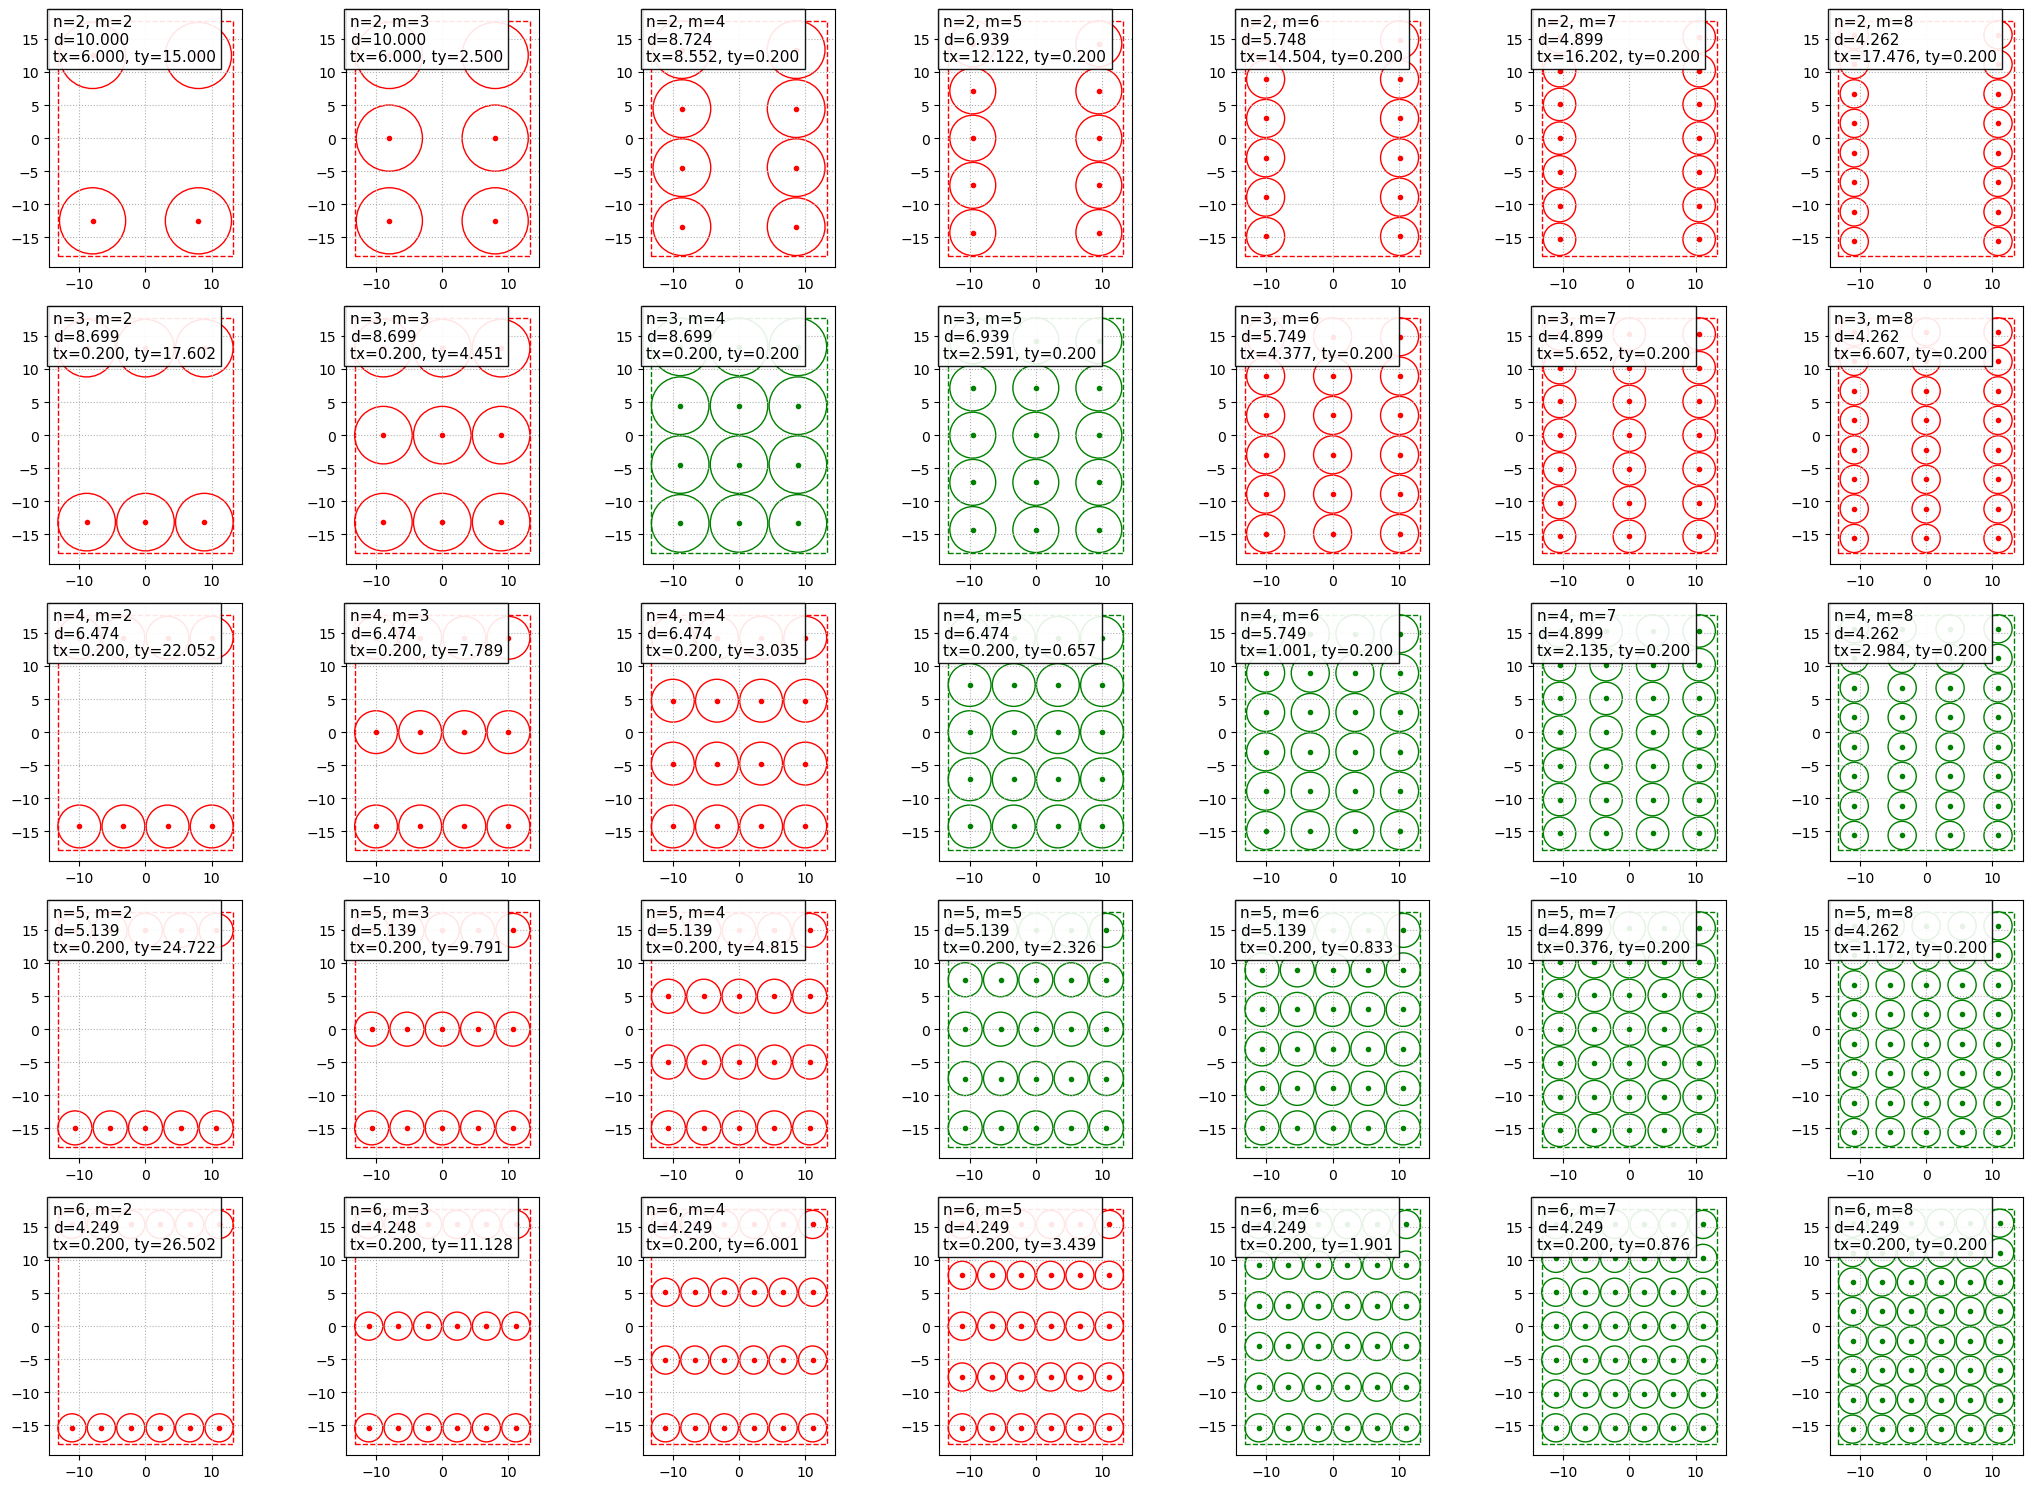

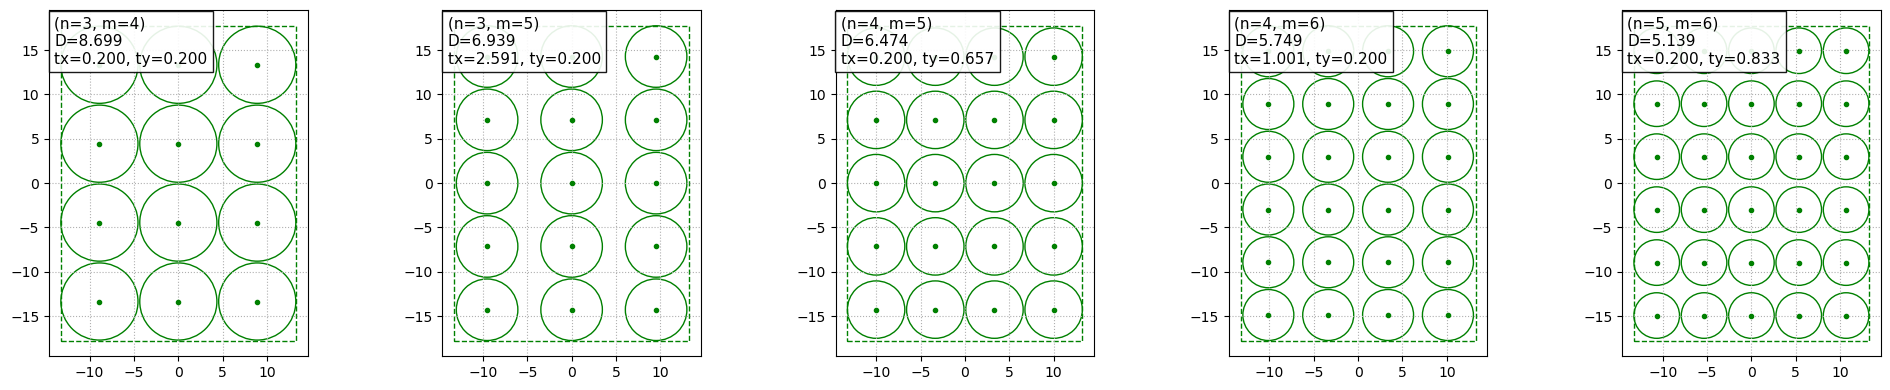

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ===================== ГИПЕРПАРАМЕТРЫ =======================
# ============================================================

X_min = 26.0
X_max = 26.5

Y_min = 35.0
Y_max = 35.5

d_min = 4.0
d_max = 10.0

n_min = 2
n_max = 14

m_min = 2
m_max = 14

num_d_steps = 6001
min_gap = 0.2
eps = 1e-9

rect_width = 26.5
rect_height = 35.5

good_gap_threshold = 3.0
plot_margin_ratio = 0.1

max_fig_width = 30
max_fig_height = 30

legend_fontsize = 11

highlight_pairs = [(3, 4), (3, 5), (4, 5), (4, 6), (5, 6)]

# ============================================================
# =================== ПОДГОТОВКА ДАННЫХ ======================
# ============================================================

n_range = range(n_min, n_max + 1)
m_range = range(m_min, m_max + 1)
d_vals = np.linspace(d_min, d_max, num_d_steps)

rect_half_w = rect_width / 2.0
rect_half_h = rect_height / 2.0

# ============================================================
# ============ ПОИСК ВСЕХ ДОПУСТИМЫХ КАНДИДАТОВ ===============
# ============================================================

candidates = []

for n in n_range:
    for m in m_range:
        for d in d_vals:
            tx_a = (X_min - n * d) / (n - 1)
            tx_b = (X_max - n * d) / (n - 1)
            tx_lo, tx_hi = min(tx_a, tx_b), max(tx_a, tx_b)

            ty_a = (Y_min - m * d) / (m - 1)
            ty_b = (Y_max - m * d) / (m - 1)
            ty_lo, ty_hi = min(ty_a, ty_b), max(ty_a, ty_b)

            if tx_hi > min_gap and ty_hi > min_gap:
                tx = max(tx_lo, min_gap + 1e-6)
                ty = max(ty_lo, min_gap + 1e-6)

                if tx <= tx_hi + eps and ty <= ty_hi + eps:
                    X = n * (d + tx) - tx
                    Y = m * (d + ty) - ty

                    if X_min <= X <= X_max and Y_min <= Y <= Y_max:
                        candidates.append({
                            "n": n, "m": m, "d": d,
                            "tx": tx, "ty": ty
                        })

# ============================================================
# ===== ФИЛЬТРАЦИЯ: ОДИН КАНДИДАТ НА (n, m) С MAX d ==========
# ============================================================

best_by_nm = {}
for c in candidates:
    key = (c["n"], c["m"])
    if key not in best_by_nm or c["d"] > best_by_nm[key]["d"]:
        best_by_nm[key] = c

# ============================================================
# ================= ПОДГОТОВКА СЕТКИ =========================
# ============================================================

ns = sorted({k[0] for k in best_by_nm})
ms = sorted({k[1] for k in best_by_nm})

n_to_row = {n: i for i, n in enumerate(ns)}
m_to_col = {m: j for j, m in enumerate(ms)}

rows = len(ns)
cols = len(ms)

max_half_x = 0.0
max_half_y = 0.0

for rec in best_by_nm.values():
    n, m = rec["n"], rec["m"]
    d, tx, ty = rec["d"], rec["tx"], rec["ty"]

    dx = d + tx
    dy = d + ty
    r = d / 2.0

    half_w = (n - 1) * dx / 2.0 + r
    half_h = (m - 1) * dy / 2.0 + r

    max_half_x = max(max_half_x, half_w, rect_half_w)
    max_half_y = max(max_half_y, half_h, rect_half_h)

xlim = (-max_half_x * (1 + plot_margin_ratio),
         max_half_x * (1 + plot_margin_ratio))
ylim = (-max_half_y * (1 + plot_margin_ratio),
         max_half_y * (1 + plot_margin_ratio))

# ============================================================
# ======================= ГРАФИК №1 =========================
# ============================================================

fig, axes = plt.subplots(
    rows, cols,
    figsize=(min(3 * cols, max_fig_width),
             min(3 * rows, max_fig_height))
)

axes = np.atleast_2d(axes)

for (n, m), rec in best_by_nm.items():
    ax = axes[n_to_row[n], m_to_col[m]]

    d, tx, ty = rec["d"], rec["tx"], rec["ty"]
    dx, dy = d + tx, d + ty
    r = d / 2.0

    good = (tx < good_gap_threshold) and (ty < good_gap_threshold)
    color = "green" if good else "red"

    xs = [(i - (n - 1) / 2) * dx for i in range(n)]
    ys = [(j - (m - 1) / 2) * dy for j in range(m)]

    for y in ys:
        for x in xs:
            ax.add_patch(plt.Circle((x, y), r, fill=False, edgecolor=color))
            ax.plot(x, y, ".", color=color)

    ax.add_patch(
        plt.Rectangle(
            (-rect_half_w, -rect_half_h),
            rect_width, rect_height,
            fill=False, linestyle="--", edgecolor=color
        )
    )

    ax.text(
        0.02, 0.98,
        f"n={n}, m={m}\nd={d:.3f}\ntx={tx:.3f}, ty={ty:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=legend_fontsize,
        bbox=dict(facecolor="white", alpha=0.9)
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":")

plt.tight_layout()
plt.show()

# ============================================================
# ======================= ГРАФИК №2 =========================
# ============================================================

fig2, axes2 = plt.subplots(1, len(highlight_pairs), figsize=(20, 4))
axes2 = np.atleast_1d(axes2)

for ax, (n, m) in zip(axes2, highlight_pairs):
    if (n, m) not in best_by_nm:
        ax.axis("off")
        continue

    rec = best_by_nm[(n, m)]
    d, tx, ty = rec["d"], rec["tx"], rec["ty"]
    dx, dy = d + tx, d + ty
    r = d / 2.0

    good = (tx < good_gap_threshold) and (ty < good_gap_threshold)
    color = "green" if good else "red"

    xs = [(i - (n - 1) / 2) * dx for i in range(n)]
    ys = [(j - (m - 1) / 2) * dy for j in range(m)]

    for y in ys:
        for x in xs:
            ax.add_patch(plt.Circle((x, y), r, fill=False, edgecolor=color))
            ax.plot(x, y, ".", color=color)

    ax.add_patch(
        plt.Rectangle(
            (-rect_half_w, -rect_half_h),
            rect_width, rect_height,
            fill=False, linestyle="--", edgecolor=color
        )
    )

    # ЛЕГЕНДА С D, tx, ty
    ax.text(
        0.02, 0.98,
        f"(n={n}, m={m})\n"
        f"D={d:.3f}\n"
        f"tx={tx:.3f}, ty={ty:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=legend_fontsize,
        bbox=dict(facecolor="white", alpha=0.9)
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":")

plt.tight_layout()
plt.savefig(
    "highlight_candidates.jpg",
    dpi=450,
    format="jpg"
)
plt.show()
